# 2026-09-01 Close-to-peak SF, Balmer non-detection, and non-SF: fractions, spatial diagnostics, and rSFMS locations

Copied from `20260901_check_pre_peak_SF_fraction_and_rSFMS_categories.ipynb`. The coloured target sample is close-to-peak,
inclination cut ($i<80^\circ$), valid-disc denominator, geometry (including the
minimum component $R/R_e$ for NGC4567_8), bins, and original SF selection are unchanged.
The original mass-radius and stellar-mass-map diagnostics are retained.

Let $V$ be the original valid-disc mask, $S$ the original SF mask, and
$D_{\rm B}=D_{\mathrm{H}\alpha}\cap D_{\mathrm{H}\beta}$ the mask where **both
Halpha and Hbeta pass detection**. For every bin, use the same $N_V$ denominator:

$$f_{\rm SF}=N(S)/N_V,\qquad
f_{\rm ND}=N(V\cap\neg D_{\rm B})/N_V,\qquad
f_{\rm NSF}=N(V\cap D_{\rm B}\cap\neg S)/N_V.$$

**ND means Halpha or Hbeta (or both) fails detection.** Weak [O III], [N II],
or [S II] lines do not assign a pixel to ND. The inherited SF selection already
requires both Balmer detections, and this notebook checks $S\subseteq D_{\rm B}$
for every included product. The three categories are therefore disjoint and sum
to one. Fractions are shown only for $N_V\ge50$.

SF remains exactly the original selection: finite `LOGSFR_SURFACE_DENSITY_HII`,
EW(Halpha)>6 Angstrom, and finite intrinsic Halpha dispersion <45 km/s.
Requiring Balmer detections again would give the same SF mask, so no additional
detected-SF fraction is defined or plotted. This does **not** impose a six-line
detection requirement on SF.

NSF means **both Balmer lines detected, but not selected as SF**; it does not
require detection of every forbidden line and does not prove absence of star
formation. It can include weak or ambiguous BPT diagnostics, low EW, high
dispersion, and unavailable ancillary measurements. These are exposed below.
The original `_HII` products and the stricter independent `NII_BPT`/`SII_BPT`
class maps have different acceptance rules. The class maps are used only to
describe rejected pixels; they never replace the original SF selection.

For each Balmer line, detection requires finite raw flux and positive finite raw
flux error, with $F/\sigma_F\ge\mathtt{CUT\_SN}$ and
$F\ge\mathtt{NOISE}$ from that gas FITS primary header. The current products
use 3 and 20 respectively; the latter is in
$10^{-20}\,{\rm erg\,s^{-1}\,cm^{-2}}$ per map pixel. These are the thresholds
in `SFR+Z.py::apply_QC`. Failing the flux floor need not imply low S/N.
Missing/invalid Balmer flux or error also prevents establishing detection and
is counted separately within ND. BPT classifications use the stored products
based on **dust-corrected** fluxes, with no new BPT or upper-limit inference here.

The valid footprint requires finite stellar density, finite gas BIN_ID, MASK==0,
and finite radius. No extra inclination correction is applied. These fractions
describe selection outcomes within that footprint, not excluded/unobserved
pixels or a physical cause of quenching.

## Fixed pre-peak rSFMS reference and close-to-peak targets

The fraction, spatial, failure-mode, and coloured rSFMS diagnostics use only the
**close-to-peak target sample**. The rSFMS comparison layer is deliberately fixed:

| Layer | Sample | Role |
|---|---|---|
| Light gray points | All selected-SF pixels from all pre-peak reference galaxies | Common visual background |
| Dotted contour | All finite SF+ND+NSF pixels from all pre-peak reference galaxies | Common outer-point outline |
| Black dashed line | Pre-peak selected SF, with $w_{ig}=1/N_{\mathrm{SF},g}$ | Equal-galaxy reference OLS |
| Blue/orange/red points | Individual close-to-peak target galaxy | Target SF/ND/NSF locations |
| Blue dashed line | Individual target selected-SF pixels | Unweighted target-galaxy OLS |

Target pixels never enter the light-gray reference, dotted reference contour, or
black reference OLS. The black fit retains the live eight-galaxy pre-peak
reference and gives every reference galaxy equal total weight. Axis limits include
both the full pre-peak reference and all finite close-to-peak target points so target
outliers are not clipped.

The three category meanings and all selection thresholds are unchanged from the
source notebook. ND proxy ordinates remain substitutions rather than formal upper
limits, and NSF ordinates are not automatically star-formation measurements.


## Important: an `UPPER` name is not a confidence limit

The current `SFR+Z.py` function `modify_Balmer_not_detected_map` constructs the
ND contribution to `LOGSFR_SURFACE_DENSITY` from
`max(NOISE, raw Halpha flux)`, without a Balmer-decrement correction.
The notebook checks that this construction matches the live stored maps.
Thus an orange horizontal floor can be imposed by the pipeline, not by galaxy
physics. Hbeta-only ND can still have detected Halpha; it is not an Halpha
non-detection. No upper-limit arrows are drawn for these placeholders.

For NSF, an upper-bound interpretation of the SF contribution would require
explicit assumptions about the emission source and attenuation. Failure of an
EW, dispersion, or classification gate alone does not define a numerical
confidence limit. No new dust correction, sensitivity prescription, or SFR
calibration is introduced here.

### Derivation provenance

- Source notebook: `20260901_check_pre_peak_SF_fraction_and_rSFMS_categories.ipynb`
- Source SHA-256 at copy time: `6b2a5458ab96c49988ff13f6118eb8d117c47ad84addcfe5b46bb60f3396bb3a`
- Target stage: `close-to-peak`
- Fixed reference stage: `pre-peak`

The source notebook is not modified by this copy. Product discovery, masks,
thresholds, geometry, and category definitions are retained; only target/reference
sample routing, labels, and the corresponding runtime assertions are changed.

## 1. Configuration and imports

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

TARGET_STAGE = "close-to-peak"
TARGET_STAGE_LABEL = "Close-to-peak"
REFERENCE_STAGE = "pre-peak"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_EDGES = np.linspace(6.0, 10.0, 13)
R_EDGES = np.arange(0.0, 1.6 + 0.2, 0.2)
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Scope: {TARGET_STAGE} targets with fixed pre-peak reference; science-ready primary samples with inclination < 80 deg")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: close-to-peak targets with fixed pre-peak reference; science-ready primary samples with inclination < 80 deg
No additional inclination correction is applied to either surface-density map.


## 2. Reusable data and measurement helpers

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {a.shape for a in (mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr)}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps


def binned_categories(values, maps, edges):
    result = binned_fraction(values, maps["valid_disc_mask"], maps["sf_mask"], edges)
    for label, key in (("ND", "nd_mask"), ("NSF", "nsf_mask")):
        extra = binned_fraction(values, maps["valid_disc_mask"], maps[key], edges)
        result["N_" + label] = extra.N_SF
        result["f_" + label] = extra.f_SF
    assert np.array_equal(result.N_SF + result.N_ND + result.N_NSF, result.N_valid)
    shown = result.N_valid >= MIN_VALID_PIXELS_PER_BIN
    assert np.allclose(result.loc[shown, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1)
    assert int(result.N_valid.sum()) == int(maps["valid_disc_mask"].sum())
    return result


def plot_category_fractions(axis, table):
    for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
        axis.plot(table.center, table["f_" + label], marker="o", ms=3, lw=1.8,
                  ls=linestyle, color=CATEGORY_COLORS[label], label=r"$f_{\rm " + label + "}$")
    axis.legend(fontsize=8, ncol=3, loc="best")


## 3. Live close-to-peak target and pre-peak reference inventory and QC

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir() if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS]),
            "ew_path": first_existing([folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
        })
    return pd.DataFrame(rows)


master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg", "center_dec_deg",
    "inclination_deg", "pa_deg_east_of_north", "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left", validate="one_to_one"
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
target_candidates = inventory.loc[
    inventory.stage.eq(TARGET_STAGE) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values("GALID").reset_index(drop=True)
reference_candidates = inventory.loc[
    inventory.stage.eq(REFERENCE_STAGE) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values("GALID").reset_index(drop=True)
all_candidates = pd.concat([reference_candidates, target_candidates], ignore_index=True)
all_candidates = all_candidates.drop_duplicates("GALID").sort_values("GALID").reset_index(drop=True)

map_cache = {}
qc_rows = []
for row in all_candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            if np.any(maps["sf_mask"] & ~maps["valid_disc_mask"]):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        map_cache[row.GALID] = maps
    qc_rows.append({
        "GALID": row.GALID, "components": row.components, "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid_stellar_pixels": int(maps["valid_disc_mask"].sum()) if maps is not None else 0,
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()) if maps is not None else 0,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"] if maps is not None else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
target_sample = target_candidates.loc[target_candidates.GALID.isin(passed_ids)].copy()
reference_prepeak = reference_candidates.loc[reference_candidates.GALID.isin(passed_ids)].copy()
TARGET_QC = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(TARGET_STAGE)].reset_index(drop=True)
PREPEAK_REFERENCE_QC = SAMPLE_QC.loc[SAMPLE_QC.stage.eq(REFERENCE_STAGE)].reset_index(drop=True)

assert target_sample.stage.eq(TARGET_STAGE).all()
assert reference_prepeak.stage.eq(REFERENCE_STAGE).all()
assert set(target_sample.GALID).isdisjoint(reference_prepeak.GALID)
display(TARGET_QC)
display(PREPEAK_REFERENCE_QC)
print(f"{TARGET_STAGE_LABEL} target products passing QC: {len(target_sample)}/{len(target_candidates)}")
print("Target included:", ", ".join(target_sample.GALID))
print(f"Pre-peak reference products passing QC: {len(reference_prepeak)}/{len(reference_candidates)}")
print("Reference included:", ", ".join(reference_prepeak.GALID))
if len(target_sample) == 0:
    raise RuntimeError(f"No {TARGET_STAGE} target galaxies passed the live product QC")
if len(reference_prepeak) == 0:
    raise RuntimeError("No pre-peak reference galaxies passed the live product QC")


Close-to-peak target products passing QC: 5/5
Target included: NGC4298, NGC4424, NGC4501, NGC4654, NGC4694
Pre-peak reference products passing QC: 8/8
Reference included: NGC4189, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4535, NGC4567_8


,GALID,components,stage,inclination_deg,N_valid_stellar_pixels,N_selected_SF_pixels,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,144157,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,8994,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,251936,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,345036,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,1058,0.0,OK


,GALID,components,stage,inclination_deg,N_valid_stellar_pixels,N_selected_SF_pixels,wcs_separation_arcsec,QC_flag
0,NGC4189,NGC4189,pre-peak,42.0,177204,96364,0.0,OK
1,NGC4254,NGC4254,pre-peak,39.0,1043477,661963,0.0,OK
2,NGC4294,NGC4294,pre-peak,74.0,179355,68833,0.0,OK
3,NGC4321,NGC4321,pre-peak,32.0,970159,454131,0.0,OK
4,NGC4351,NGC4351,pre-peak,48.0,180133,30711,0.0,OK
5,NGC4383,NGC4383,pre-peak,56.0,227031,25212,0.0,OK
6,NGC4535,NGC4535,pre-peak,48.0,525101,187113,0.0,OK
7,NGC4567_8,"NGC4567,NGC4568",pre-peak,70.0,510118,222533,0.0,OK


## 4. Three side-by-side diagnostics for each close-to-peak target galaxy

The first two panels use the same minimum denominator as the source SF-fraction notebook: a bin is shown only with at least 50 valid disc pixels. In the third panel, the all-pixel median requires at least 50 valid pixels and the selected-SF median requires at least 20 SF pixels.

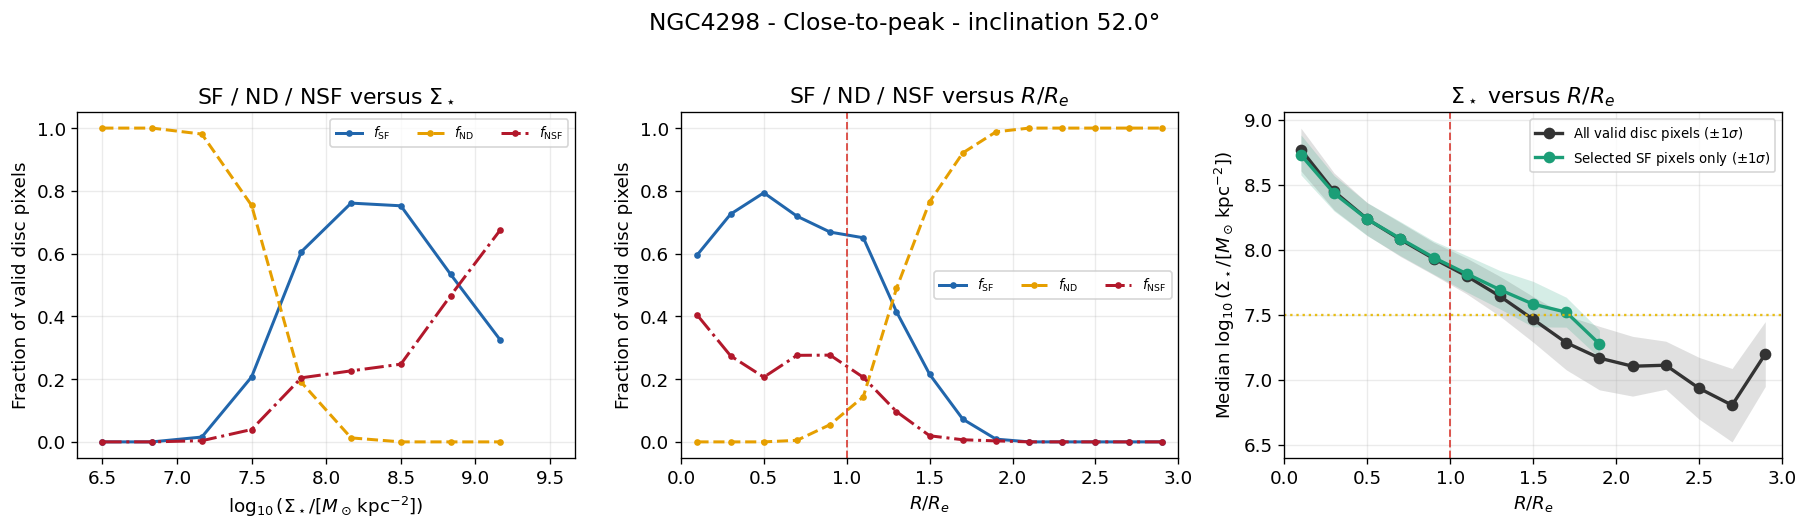

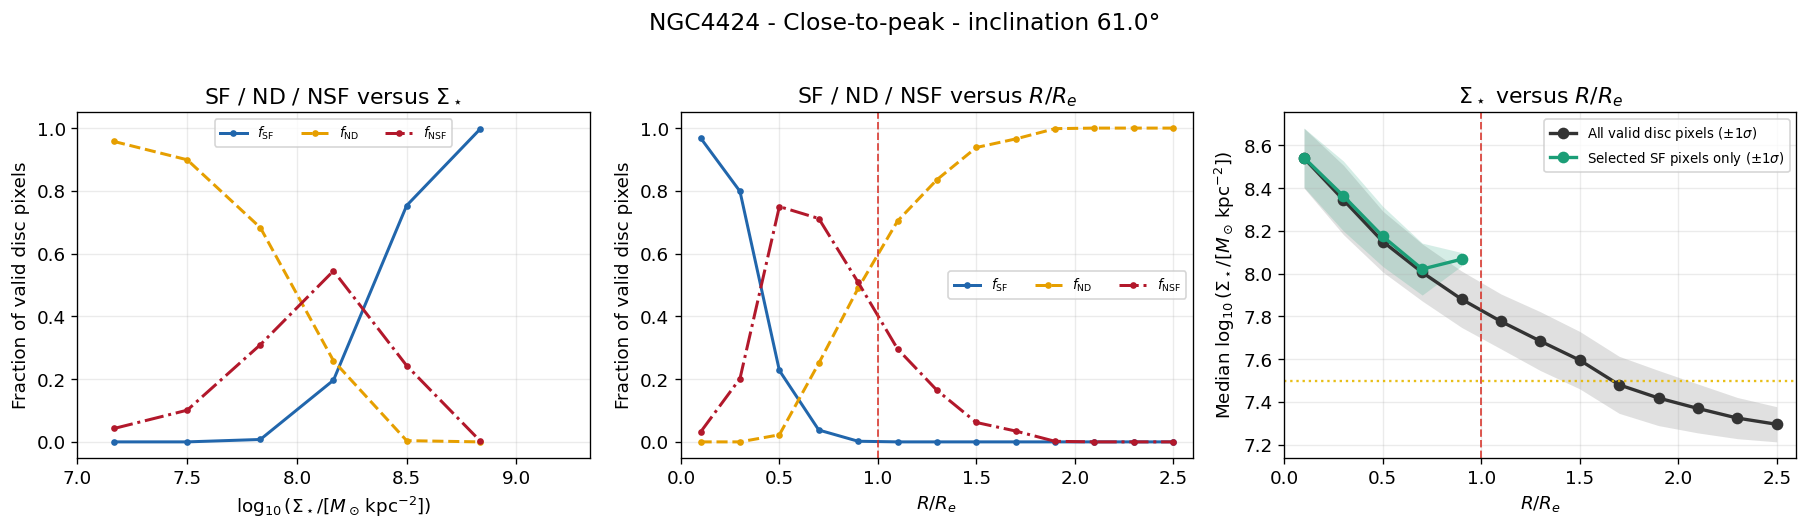

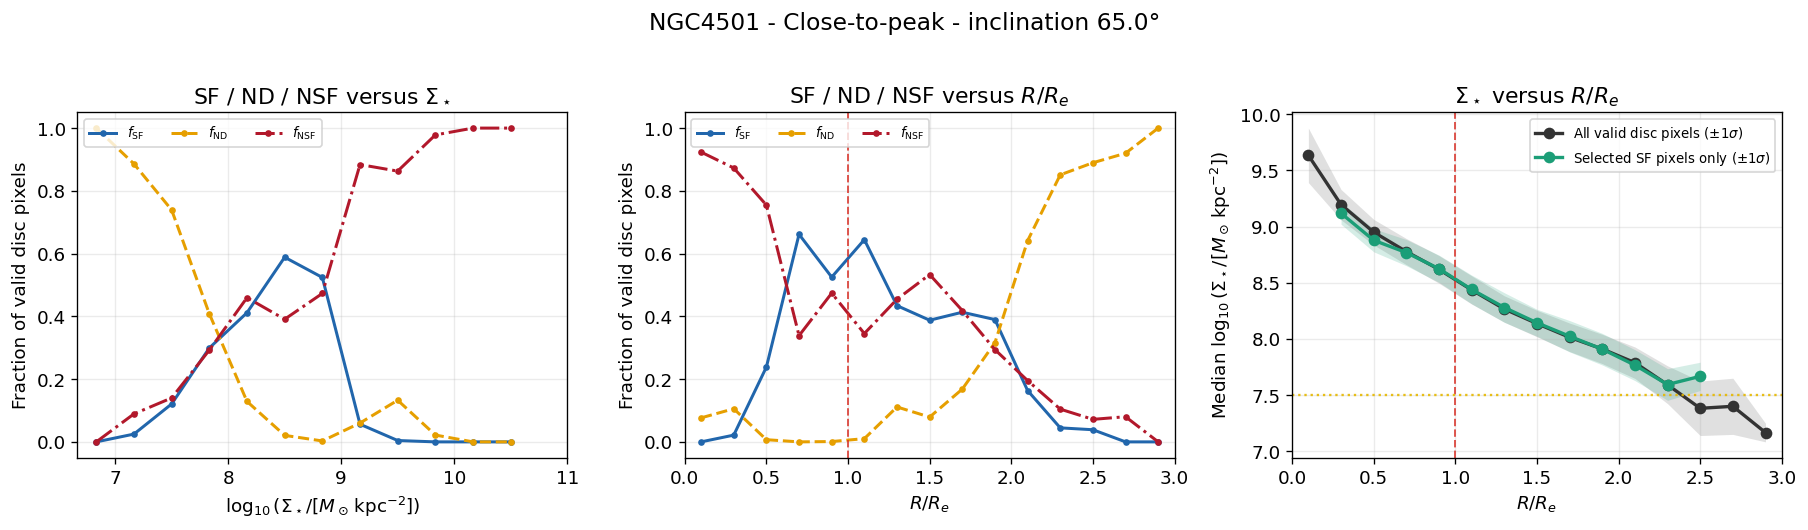

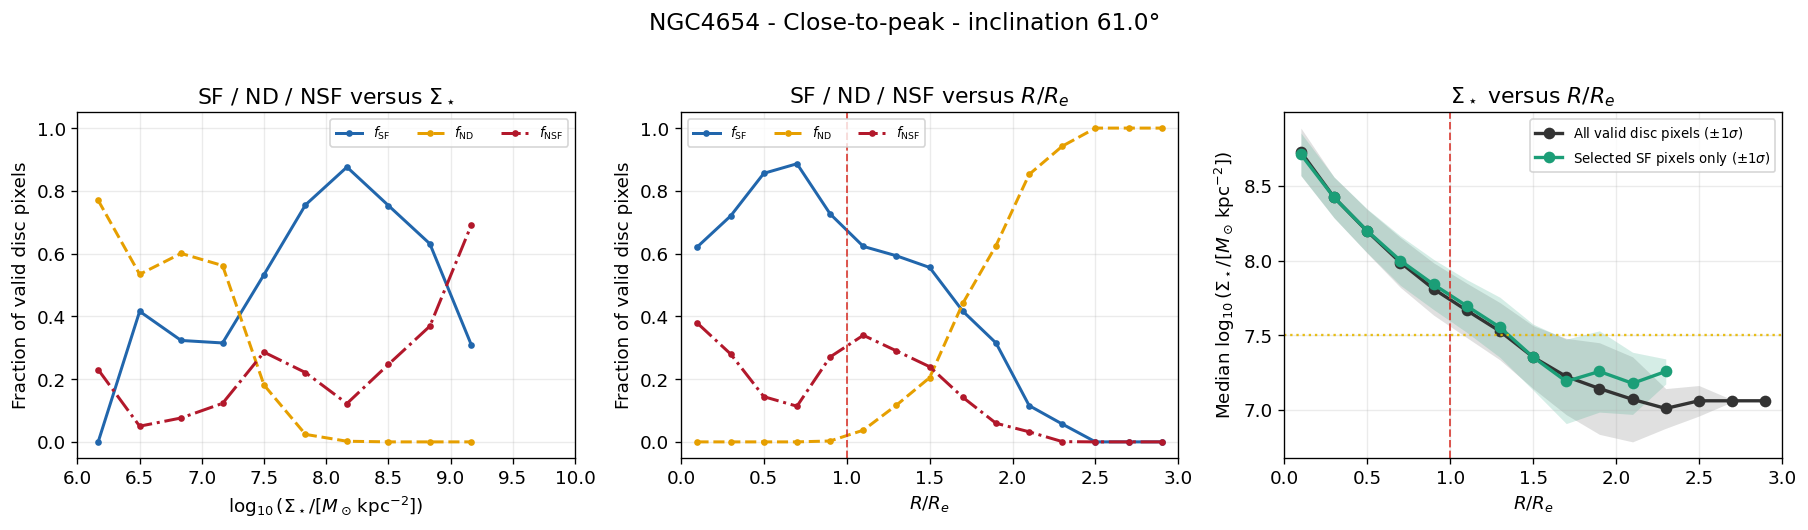

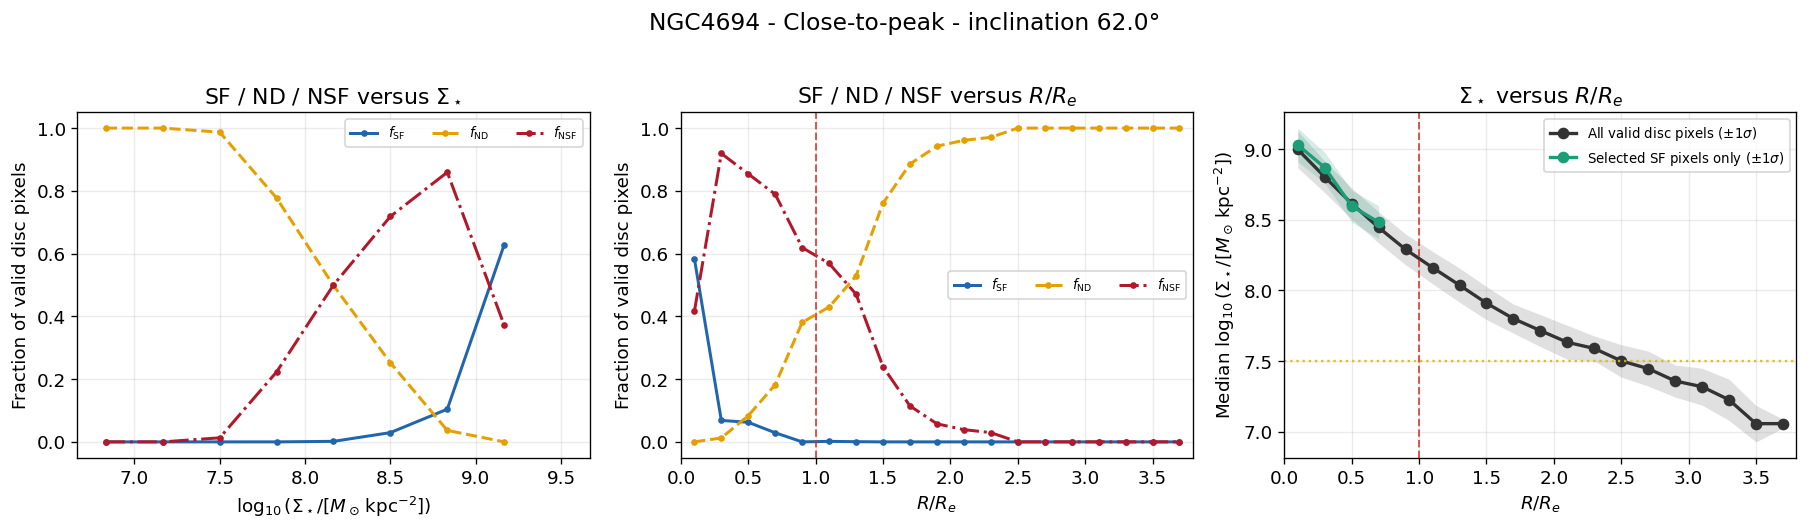

In [4]:
individual_measurements = {}


def complete_bin_edges(values, valid_mask, bin_width, *, lower_limit=None):
    """Return aligned edges that include the full finite range of valid values."""
    finite_values = np.asarray(values, dtype=float)[valid_mask & np.isfinite(values)]
    if finite_values.size == 0:
        raise ValueError("Cannot construct bins from an empty valid range")
    data_min = float(np.nanmin(finite_values))
    data_max = float(np.nanmax(finite_values))
    start = (
        float(lower_limit)
        if lower_limit is not None
        else np.floor(data_min / bin_width) * bin_width
    )
    stop = (np.floor(data_max / bin_width) + 1.0) * bin_width
    return np.arange(start, stop + 0.5 * bin_width, bin_width)


SIGMA_BIN_WIDTH = float(np.median(np.diff(SIGMA_EDGES)))
RADIUS_BIN_WIDTH = float(np.median(np.diff(R_EDGES)))

for row in target_sample.itertuples(index=False):
    maps = map_cache[row.GALID]
    galaxy_sigma_edges = complete_bin_edges(
        maps["log_sigma_star"], maps["valid_disc_mask"], SIGMA_BIN_WIDTH
    )
    galaxy_radius_edges = complete_bin_edges(
        maps["radius_re"], maps["valid_disc_mask"], RADIUS_BIN_WIDTH, lower_limit=0.0
    )
    by_sigma = binned_categories(
        maps["log_sigma_star"], maps, galaxy_sigma_edges
    )
    by_radius = binned_categories(
        maps["radius_re"], maps, galaxy_radius_edges
    )
    mass_by_radius = radial_mass_trends(maps, galaxy_radius_edges)

    # For the mass-radius panel, calculate the actual scatter in log Sigma_star
    # independently for all valid pixels and for selected SF pixels.
    all_std, sf_std = [], []
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    for lo, hi in zip(galaxy_radius_edges[:-1], galaxy_radius_edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        all_std.append(
            np.nanstd(mass[all_pixels], ddof=1)
            if int(all_pixels.sum()) >= MIN_VALID_PIXELS_PER_BIN else np.nan
        )
        sf_std.append(
            np.nanstd(mass[sf_pixels], ddof=1)
            if int(sf_pixels.sum()) >= MIN_SF_PIXELS_PER_BIN else np.nan
        )
    mass_by_radius["all_std"] = all_std
    mass_by_radius["sf_std"] = sf_std

    individual_measurements[row.GALID] = {
        "fSF_by_sigma": by_sigma,
        "fSF_by_radius": by_radius,
        "mass_by_radius": mass_by_radius,
        "sigma_edges": galaxy_sigma_edges,
        "radius_edges": galaxy_radius_edges,
    }

    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.3))
    fig.suptitle(
        f"{row.GALID} - {TARGET_STAGE_LABEL} - inclination {row.inclination:.1f}°",
        fontsize=14, y=1.02,
    )

    plot_category_fractions(axes[0], by_sigma)
    axes[0].set(
        xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $\Sigma_\star$",
        xlim=(galaxy_sigma_edges[0], galaxy_sigma_edges[-1]), ylim=(-0.05, 1.05),
    )
    plot_category_fractions(axes[1], by_radius)
    axes[1].set(
        xlabel=r"$R/R_e$", ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)
    axes[2].fill_between(
        mass_by_radius.radius_center,
        mass_by_radius.all_median - mass_by_radius.all_std,
        mass_by_radius.all_median + mass_by_radius.all_std,
        color="0.2", alpha=0.15, linewidth=0,
    )
    axes[2].fill_between(
        mass_by_radius.radius_center,
        mass_by_radius.sf_median - mass_by_radius.sf_std,
        mass_by_radius.sf_median + mass_by_radius.sf_std,
        color="#1b9e77", alpha=0.18, linewidth=0,
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.all_median,
        marker="o", lw=2.0, color="0.2", label=r"All valid disc pixels ($\pm1\sigma$)",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.sf_median,
        marker="o", lw=2.0, color="#1b9e77", label=r"Selected SF pixels only ($\pm1\sigma$)",
    )
    axes[2].set(
        xlabel=r"$R/R_e$",
        ylabel=r"Median $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        title=r"$\Sigma_\star$ versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]),
    )
    axes[2].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)
    axes[2].axhline(MASS_CONTOUR_LEVEL, color="#e6b800", ls=":", lw=1.4, alpha=0.9)
    axes[2].legend(fontsize=8)

    for axis in axes:
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

### Interpretation guide

- $f_{\rm SF}$ is the fraction of valid disc pixels in the bin that pass the unchanged H II + EW + intrinsic-dispersion SF selection.
- The third panel compares like-for-like radial bins within the same galaxy. A separation between the black and green tracks indicates that the selected SF pixels occupy a different $\Sigma_\star$ distribution from the full valid disc footprint at that radius.
- The dashed vertical line marks $R/R_e=1$; the dotted yellow horizontal guide marks $\log\Sigma_\star=7.5$, matching the contour used below.
- SF (blue), ND (orange), and NSF (red) share the original denominator and sum to one in every supported bin.
- ND means at least one Balmer line fails its detection cut. NSF means both Balmer lines pass but the original SF selection fails; weak forbidden lines, ambiguous classification, or missing ancillary measurements may still be present. Inspect the reason diagnostics before assigning a physical interpretation.


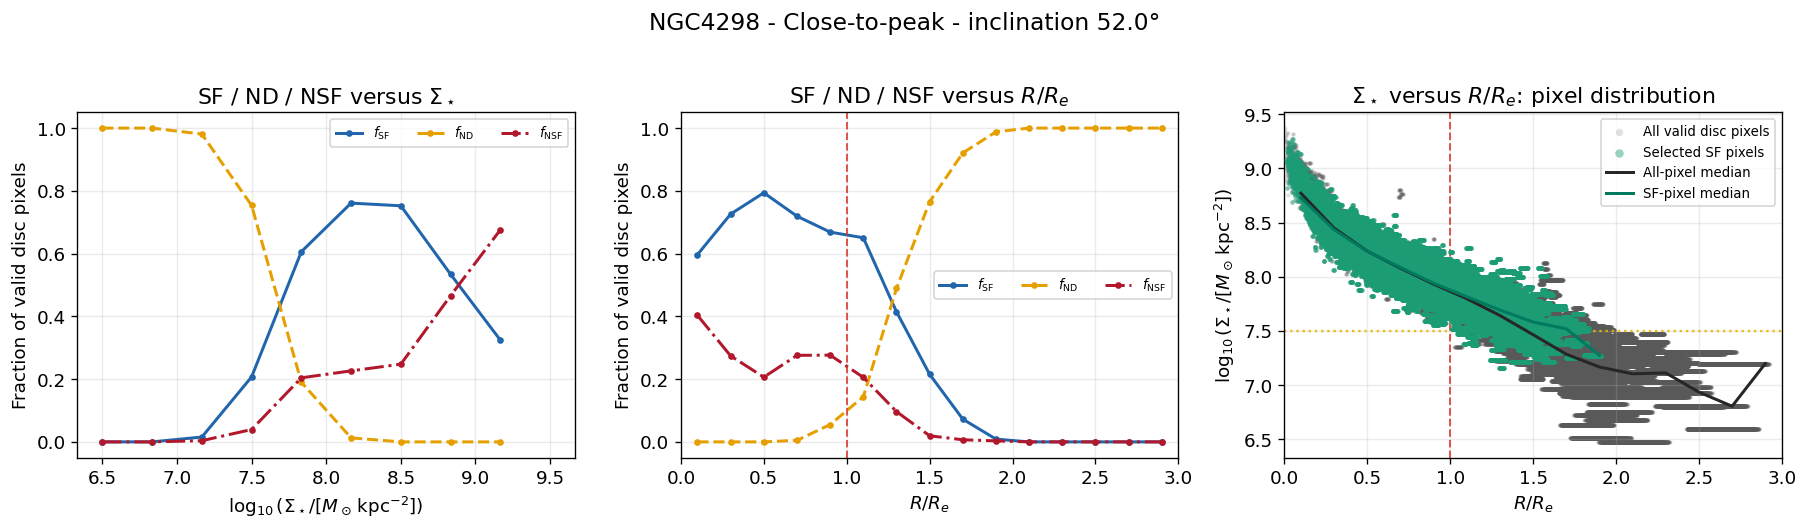

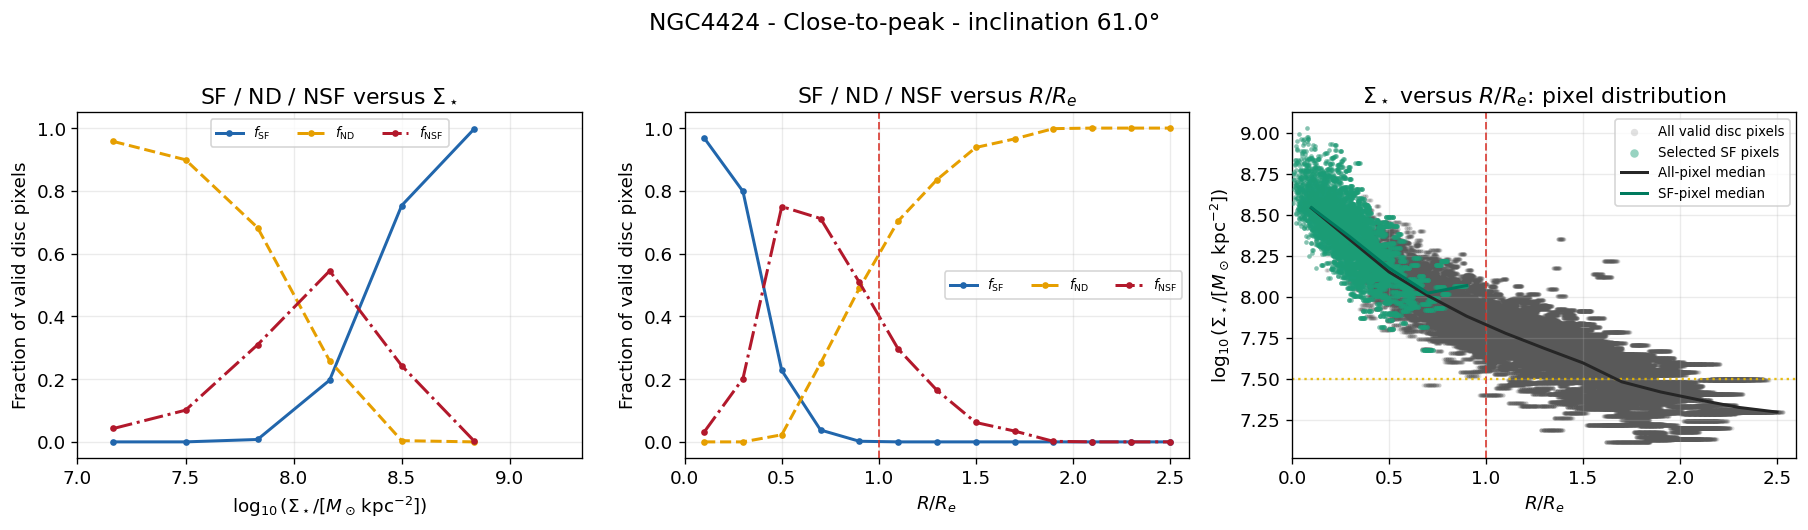

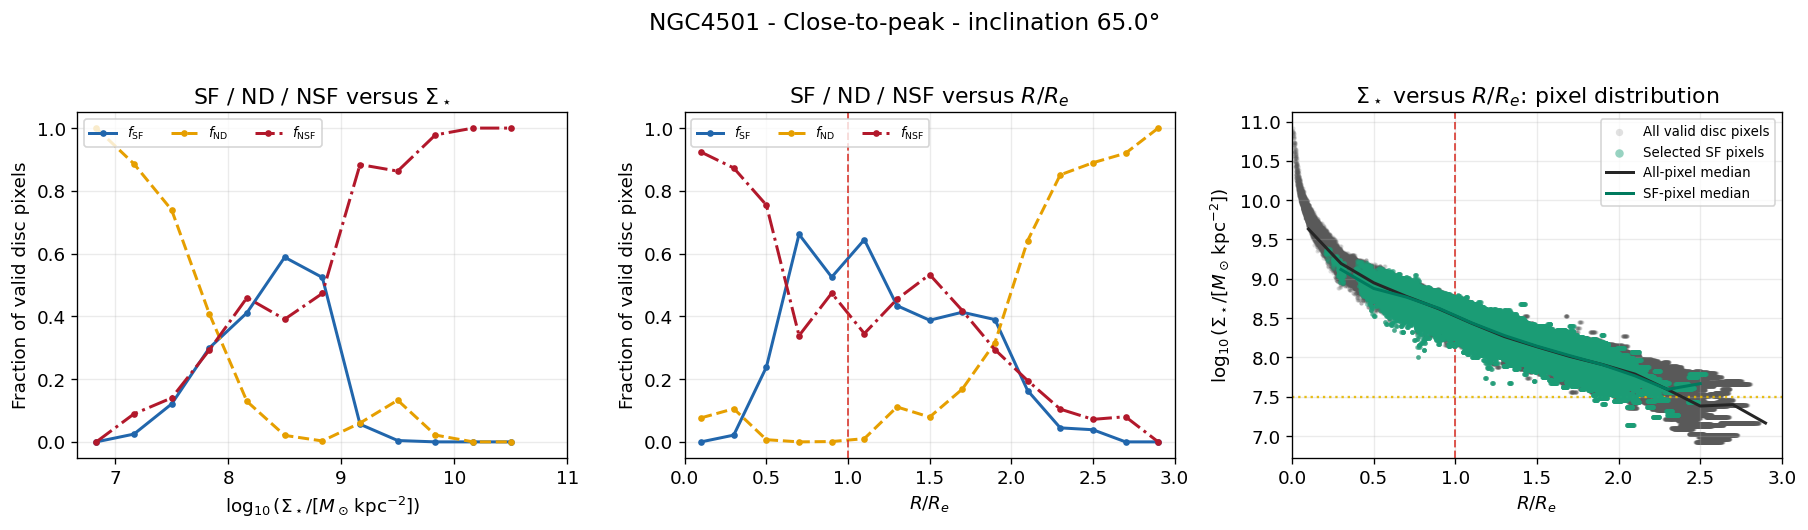

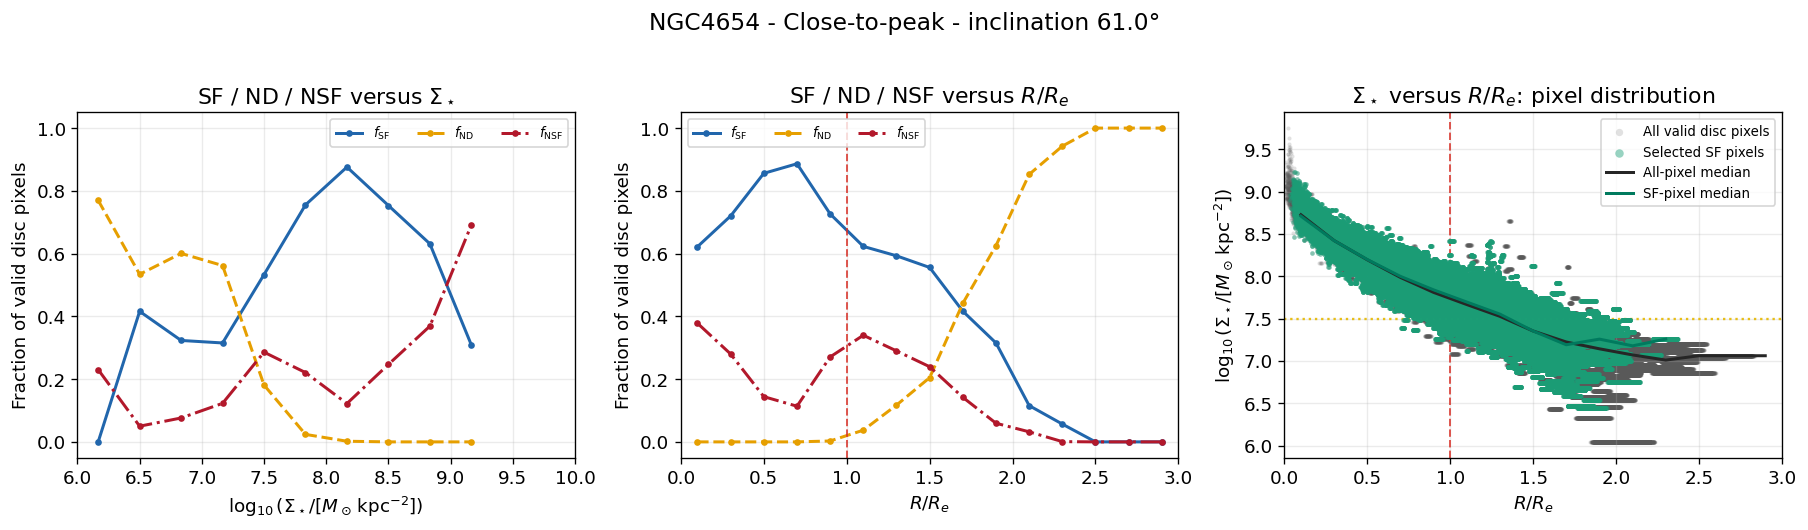

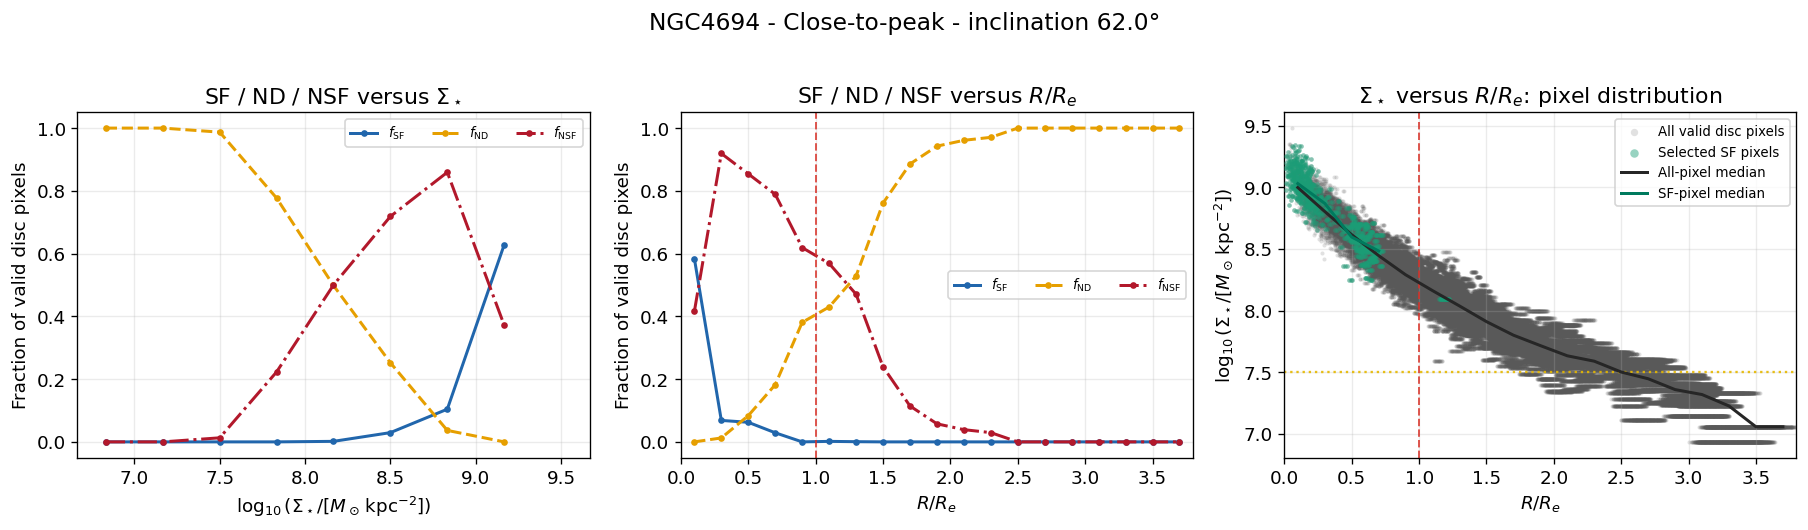

In [5]:
# Recreate the cell 9 diagnostics with the full pixel distributions in panel 3.
for row in target_sample.itertuples(index=False):
    maps = map_cache[row.GALID]
    measurements = individual_measurements[row.GALID]
    by_sigma = measurements["fSF_by_sigma"]
    by_radius = measurements["fSF_by_radius"]
    mass_by_radius = measurements["mass_by_radius"]
    galaxy_sigma_edges = measurements["sigma_edges"]
    galaxy_radius_edges = measurements["radius_edges"]

    fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.3))
    fig.suptitle(
        f"{row.GALID} - {TARGET_STAGE_LABEL} - inclination {row.inclination:.1f}°",
        fontsize=14, y=1.02,
    )

    plot_category_fractions(axes[0], by_sigma)
    axes[0].set(
        xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $\Sigma_\star$",
        xlim=(galaxy_sigma_edges[0], galaxy_sigma_edges[-1]), ylim=(-0.05, 1.05),
    )
    plot_category_fractions(axes[1], by_radius)
    axes[1].set(
        xlabel=r"$R/R_e$", ylabel="Fraction of valid disc pixels",
        title=r"SF / ND / NSF versus $R/R_e$",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]), ylim=(-0.05, 1.05),
    )
    axes[1].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8)

    all_pixels = maps["valid_disc_mask"]
    sf_pixels = maps["sf_mask"]
    axes[2].scatter(
        maps["radius_re"][all_pixels], maps["log_sigma_star"][all_pixels],
        s=6, color="0.35", alpha=0.18, linewidths=0, rasterized=True, zorder=1,
        label="All valid disc pixels",
    )
    axes[2].scatter(
        maps["radius_re"][sf_pixels], maps["log_sigma_star"][sf_pixels],
        s=8, color="#1b9e77", alpha=0.45, linewidths=0, rasterized=True, zorder=3,
        label="Selected SF pixels",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.all_median,
        lw=1.8, color="0.15", zorder=4, label="All-pixel median",
    )
    axes[2].plot(
        mass_by_radius.radius_center, mass_by_radius.sf_median,
        lw=1.8, color="#007a5e", zorder=5, label="SF-pixel median",
    )
    axes[2].set(
        xlabel=r"$R/R_e$",
        ylabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
        title=r"$\Sigma_\star$ versus $R/R_e$: pixel distribution",
        xlim=(galaxy_radius_edges[0], galaxy_radius_edges[-1]),
    )
    axes[2].axvline(1.0, color="#d73027", ls="--", lw=1.2, alpha=0.8, zorder=2)
    axes[2].axhline(
        MASS_CONTOUR_LEVEL, color="#e6b800", ls=":", lw=1.4, alpha=0.9, zorder=2
    )
    axes[2].legend(fontsize=8, markerscale=1.8)

    for axis in axes:
        axis.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 5. Close-to-peak stellar-mass maps with $R_e$ and $\log\Sigma_\star=7.5$ boundaries

The map styling follows cell 7 of the 2026-08-20 source notebook: grayscale stellar mass, the selected H II-region SFR overlay, and a red $R_e$ boundary. The new yellow contour marks the boundary at $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])=7.5$.

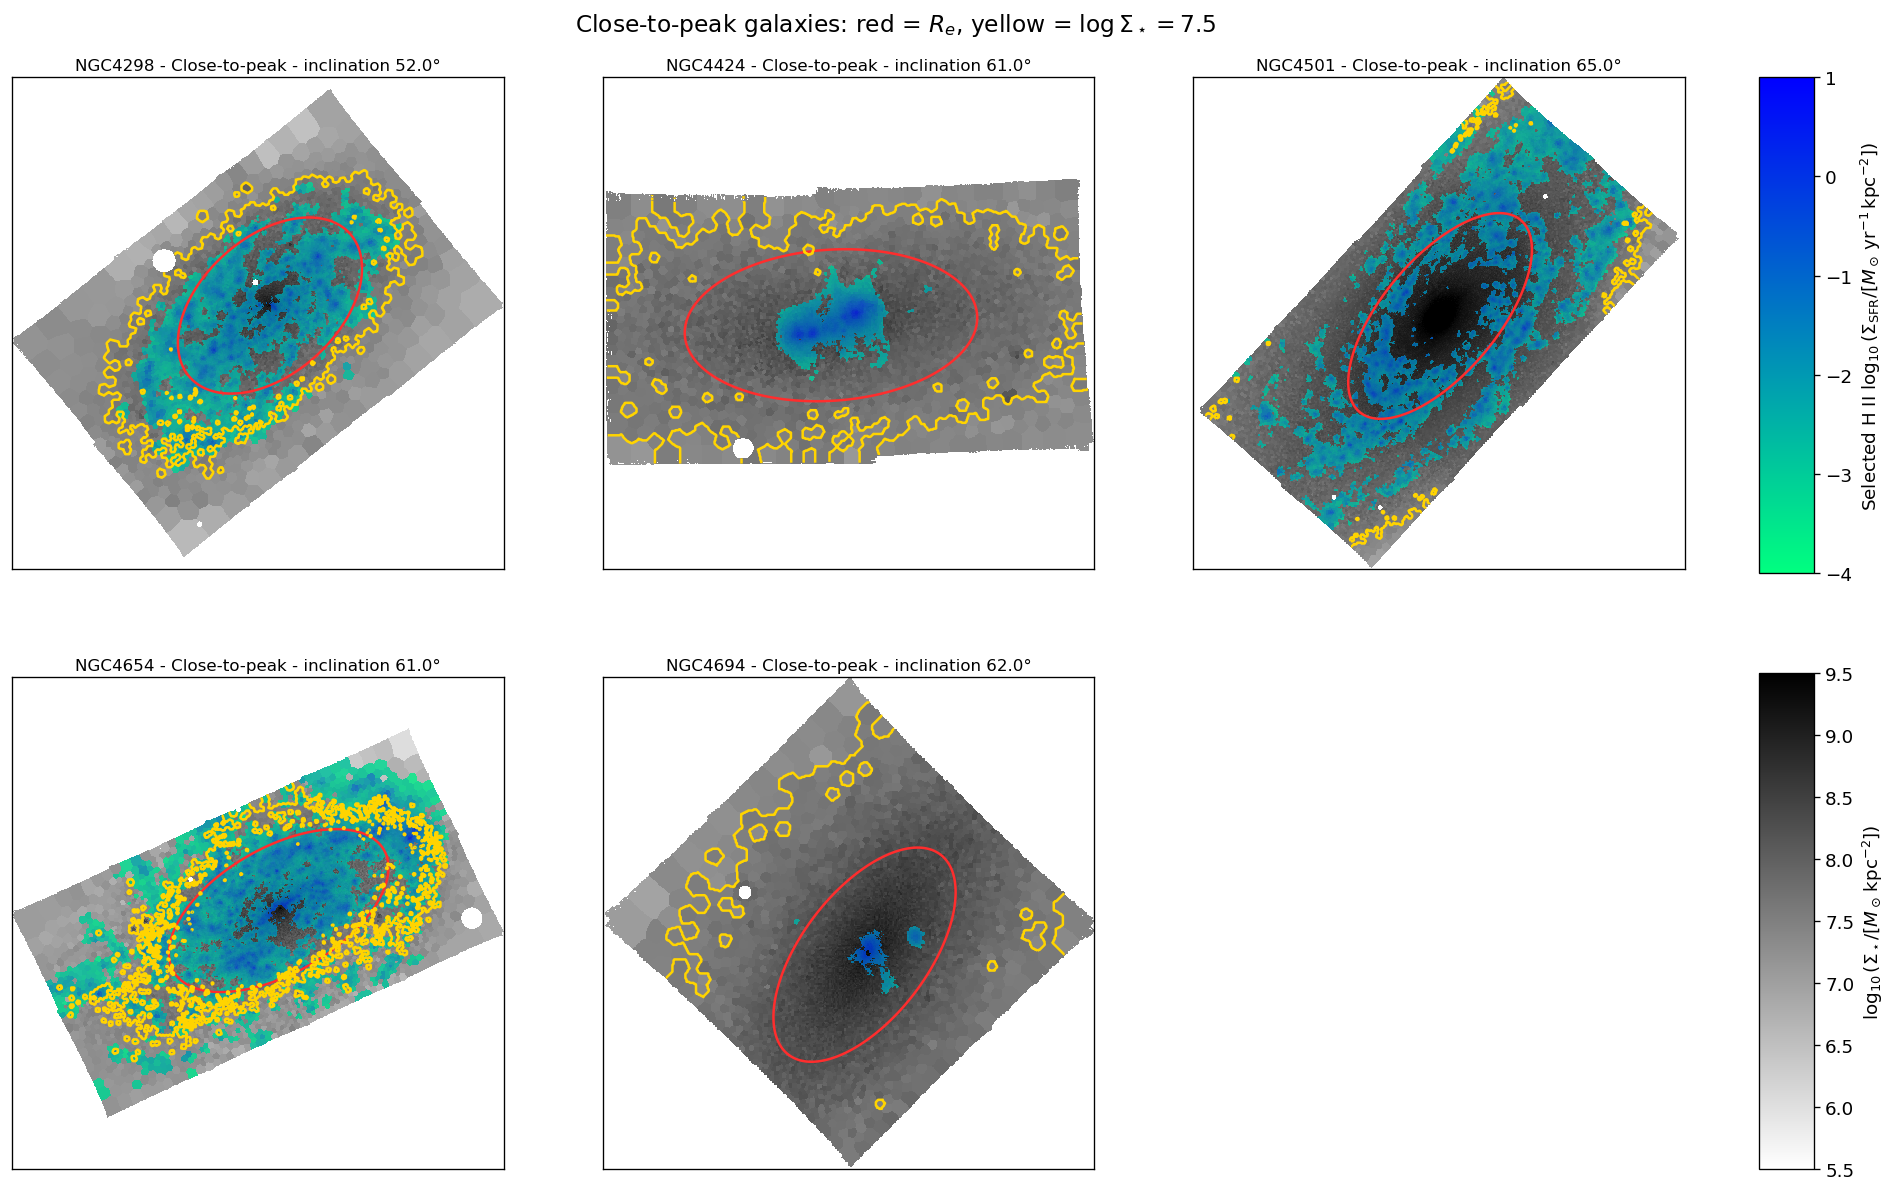

,GALID,inclination_deg,N_valid_pixels,N_selected_SF_pixels,N_finite_mass_pixels_ge_7p5,Re_boundary_drawn,logSigmaStar_7p5_boundary_drawn
0,NGC4298,52.0,498540,144157,231333,True,True
1,NGC4424,61.0,172561,8994,126955,True,True
2,NGC4501,65.0,664236,251936,637771,True,True
3,NGC4654,61.0,659231,345036,294954,True,True
4,NGC4694,62.0,94538,1058,77849,True,True


In [6]:
ncols = min(3, len(target_sample))
nrows = math.ceil(len(target_sample) / ncols)

# Match the reference notebook: maps occupy the main grid and the two vertical
# colorbars share a narrow right-hand column, with SFR above stellar mass.
fig = plt.figure(figsize=(5.1 * ncols + 0.8, 5.0 * nrows), constrained_layout=False)
map_grid = fig.add_gridspec(
    nrows, ncols + 1, width_ratios=[1] * ncols + [0.10]
)
axes = np.asarray([
    [fig.add_subplot(map_grid[row_index, column_index]) for column_index in range(ncols)]
    for row_index in range(nrows)
])
colorbar_grid = map_grid[:, ncols].subgridspec(2, 1, hspace=0.20)
sfr_colorbar_axis = fig.add_subplot(colorbar_grid[0, 0])
mass_colorbar_axis = fig.add_subplot(colorbar_grid[1, 0])

mass_norm = mpl.colors.Normalize(vmin=5.5, vmax=9.5)
sfr_norm = mpl.colors.Normalize(vmin=-4.0, vmax=1.0)
sfr_cmap = mpl.colormaps["winter_r"].copy()
sfr_cmap.set_bad((0.0, 0.0, 0.0, 0.0))

map_audit_rows = []
for axis, row in zip(axes.ravel(), target_sample.itertuples(index=False)):
    maps = map_cache[row.GALID]
    mass = maps["log_sigma_star"]
    radius = maps["radius_re"]
    sfr_overlay = np.ma.masked_where(~maps["sf_mask"], maps["log_sigma_sfr"])

    axis.imshow(mass, origin="lower", cmap="gray_r", norm=mass_norm, interpolation="nearest")
    axis.imshow(
        sfr_overlay, origin="lower", cmap=sfr_cmap, norm=sfr_norm,
        interpolation="nearest", alpha=0.82,
    )
    re_contour = axis.contour(
        radius, levels=[1.0], colors="#ff2d2d", linewidths=1.5, origin="lower"
    )
    sigma_contour = axis.contour(
        mass, levels=[MASS_CONTOUR_LEVEL], colors="#ffd400", linewidths=1.5, origin="lower"
    )
    axis.set_title(
        f"{row.GALID} - {TARGET_STAGE_LABEL} - inclination {row.inclination:.1f}°",
        fontsize=10, pad=4,
    )
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_box_aspect(1)
    map_audit_rows.append({
        "GALID": row.GALID,
        "inclination_deg": row.inclination,
        "N_valid_pixels": int(maps["valid_disc_mask"].sum()),
        "N_selected_SF_pixels": int(maps["sf_mask"].sum()),
        "N_finite_mass_pixels_ge_7p5": int((np.isfinite(mass) & (mass >= MASS_CONTOUR_LEVEL)).sum()),
        "Re_boundary_drawn": bool(len(re_contour.allsegs[0]) > 0),
        "logSigmaStar_7p5_boundary_drawn": bool(len(sigma_contour.allsegs[0]) > 0),
    })

for axis in axes.ravel()[len(target_sample):]:
    axis.axis("off")

mass_sm = mpl.cm.ScalarMappable(norm=mass_norm, cmap="gray_r")
sfr_sm = mpl.cm.ScalarMappable(norm=sfr_norm, cmap=sfr_cmap)
sfr_cbar = fig.colorbar(sfr_sm, cax=sfr_colorbar_axis)
sfr_cbar.set_label(
    r"Selected H II $\log_{10}(\Sigma_{\rm SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$"
)
mass_cbar = fig.colorbar(mass_sm, cax=mass_colorbar_axis)
mass_cbar.set_label(r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$")

fig.suptitle(
    rf"{TARGET_STAGE_LABEL} galaxies: red = $R_e$, yellow = $\log\Sigma_\star=7.5$",
    fontsize=14, y=0.995,
)
fig.subplots_adjust(left=0.03, right=0.975, bottom=0.03, top=0.94, wspace=0.12, hspace=0.22)
TARGET_MAP_AUDIT = pd.DataFrame(map_audit_rows)
plt.show()
plt.close(fig)
display(TARGET_MAP_AUDIT)

## 6. Why does selection fail?

The next table and stacked bars give one row per close-to-peak target product, without pooling
pixels across galaxies. They describe the full valid footprint (the profile bins
also span its full range). No independent-spaxel errors or environmental significance
are inferred; pixels share the PSF and may share fitted bins.

ND is based only on Halpha/Hbeta detection. Its invalid-measurement and
measured-below-cut counts partition the orange category, using only those two lines.
SF and NSF together partition the pixels with **both Balmer lines detected**.
All three fractions retain the original valid-disc denominator. There is no
additional detected-SF fraction or conditional-SF curve.


,GALID,N_valid,N_SF,N_ND,N_NSF,f_SF,f_ND,f_NSF,N_ND_invalid_measurement,N_ND_measured_below_cut
0,NGC4298,498540,144157,310344,44039,0.2892,0.6225,0.0883,0,310344
1,NGC4424,172561,8994,124594,38973,0.0521,0.7220,0.2259,0,124594
2,NGC4501,664236,251936,148840,263460,0.3793,0.2241,0.3966,0,148840
3,NGC4654,659231,345036,189799,124396,0.5234,0.2879,0.1887,0,189799
4,NGC4694,94538,1058,65319,28161,0.0112,0.6909,0.2979,0,65319


,GALID,gas_path,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW
0,NGC4298,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
1,NGC4424,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
2,NGC4501,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
3,NGC4654,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti
4,NGC4694,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti


reason,BPT: stable non-HII,BPT: weak/ambiguous/unavailable,Dispersion >= 45,Dispersion unavailable,EW <= 6,EW unavailable,HII SFR unavailable
GALID,,,,,,,
NGC4298,7472,20074,471,0,16022,0,0
NGC4424,10445,17091,7490,0,3947,0,0
NGC4501,104026,147612,248,0,11574,0,0
NGC4654,46996,68022,3552,0,5826,0,0
NGC4694,16205,10367,894,0,695,0,0


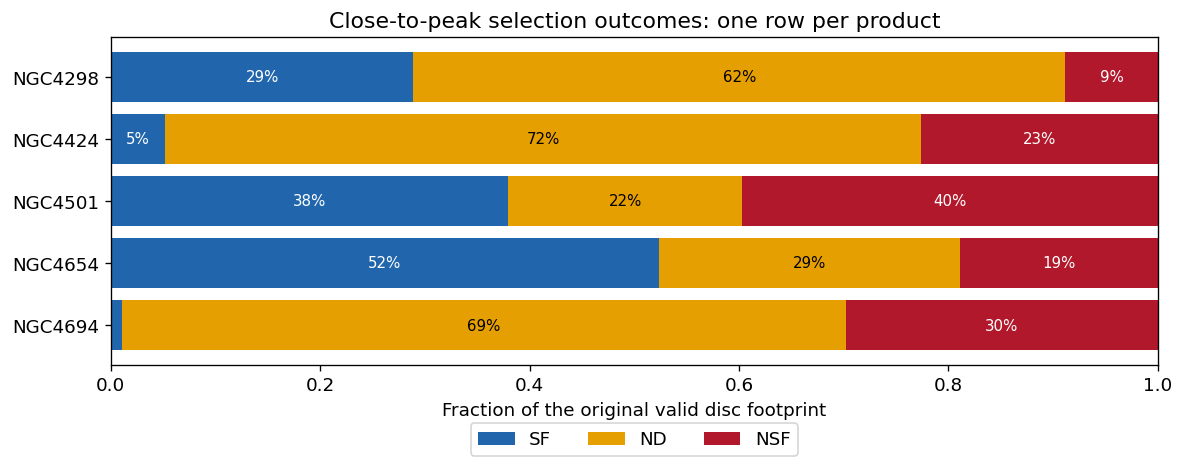

In [7]:

summary_rows, provenance_rows, reason_rows = [], [], []
for row in target_sample.itertuples(index=False):
    maps = map_cache[row.GALID]
    n = int(maps["valid_disc_mask"].sum())
    counts = {label: int(maps[key].sum()) for label, key in
              (("SF", "sf_mask"), ("ND", "nd_mask"), ("NSF", "nsf_mask"))}
    n_balmer = int((maps["valid_disc_mask"] & maps["balmer_detected_mask"]).sum())
    assert counts["SF"] + counts["NSF"] == n_balmer
    summary_rows.append({
        "GALID": row.GALID, "N_valid": n,
        **{"N_" + key: value for key, value in counts.items()},
        **{"f_" + key: counts[key] / n for key in ("SF", "ND", "NSF")},
        "N_ND_invalid_measurement": int(maps["nd_invalid_mask"].sum()),
        "N_ND_measured_below_cut": int(maps["nd_measured_below_cut_mask"].sum()),
    })
    provenance_rows.append({"GALID": row.GALID, "gas_path": str(row.sfr_path),
                            **maps["detection_provenance"]})
    for label, mask in maps["nsf_reasons"].items():
        reason_rows.append({"GALID": row.GALID, "reason": label, "N_pixels": int(mask.sum()),
                            "fraction_of_valid": mask.sum() / n})
CATEGORY_SUMMARY = pd.DataFrame(summary_rows)
DETECTION_PROVENANCE = pd.DataFrame(provenance_rows)
NSF_REASON_COUNTS = pd.DataFrame(reason_rows)
display(CATEGORY_SUMMARY.round(4))
display(DETECTION_PROVENANCE)
display(NSF_REASON_COUNTS.pivot(index="GALID", columns="reason", values="N_pixels"))

fig, ax = plt.subplots(figsize=(10, 0.48 * len(target_sample) + 1.7))
left = np.zeros(len(target_sample))
for label in ("SF", "ND", "NSF"):
    vals = CATEGORY_SUMMARY["f_" + label].to_numpy()
    ax.barh(CATEGORY_SUMMARY.GALID, vals, left=left, color=CATEGORY_COLORS[label], label=label)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v >= 0.045:
            ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=9,
                    color="black" if label == "ND" else "white")
    left += vals
ax.set(xlim=(0, 1), xlabel="Fraction of the original valid disc footprint",
       title=f"{TARGET_STAGE_LABEL} selection outcomes: one row per product")
ax.invert_yaxis()
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15))
fig.tight_layout()
plt.show()
plt.close(fig)


### Spatial categories, Balmer failures, and NSF rejection gates

Each galaxy has three additional panels:

1. A categorical map of the **same valid footprint**, with white outside it.
   Red and yellow contours retain $R_e$ and $\log\Sigma_\star=7.5$.
2. For Halpha and Hbeta separately, the fraction of valid pixels failing that
   line's detection cut, versus radius. The two curves overlap where both fail;
   their union is the black dashed $f_{\rm ND}$ curve.
3. An exclusive breakdown of NSF (both Balmer lines detected), versus radius,
   evaluated in order: unavailable H II SFR (split into stable non-HII BPT,
   weak/ambiguous/unavailable BPT, or both class maps HII but SFR unavailable),
   then missing EW, EW<=6, missing intrinsic dispersion, dispersion>=45.
   These curves sum to the black dashed $f_{\rm NSF}$. Earlier failures take
   priority when cuts overlap.

Stable non-HII means at least one independent BPT class map has code 2 or 3.
The weak/ambiguous/unavailable group includes code 0/-1 when no stable non-HII
diagnostic has already identified the pixel. In particular, **forbidden-line
non-detections can fall within NSF rather than ND**. This group is not a secure
non-HII classification. The independent BPT maps are stricter than `_HII`
selection and are used here only to describe pixels without finite H II SFR.

The inherited intrinsic-dispersion calculation returns NaN when
$\sigma_{\rm obs}^2-\sigma_{\rm corr}^2\le0$; such unresolved/invalid measurements
belong to **dispersion unavailable**, not the high-dispersion group. No original
SF selection is repaired or relaxed here. All profile denominators remain the
valid disc pixels in the bin, with the same 50-pixel minimum. First-failed gates
are bookkeeping, not evidence of a unique physical mechanism.


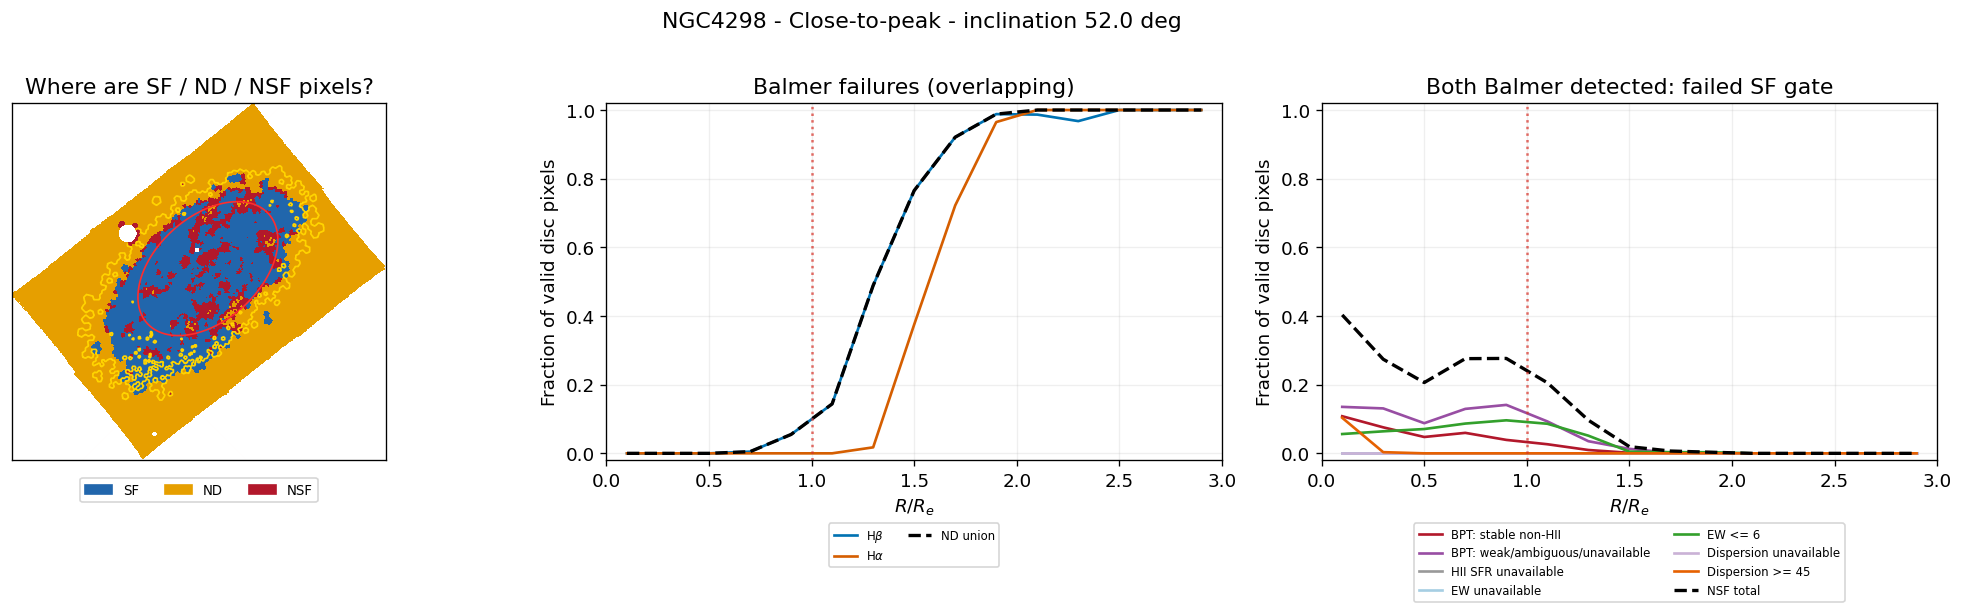

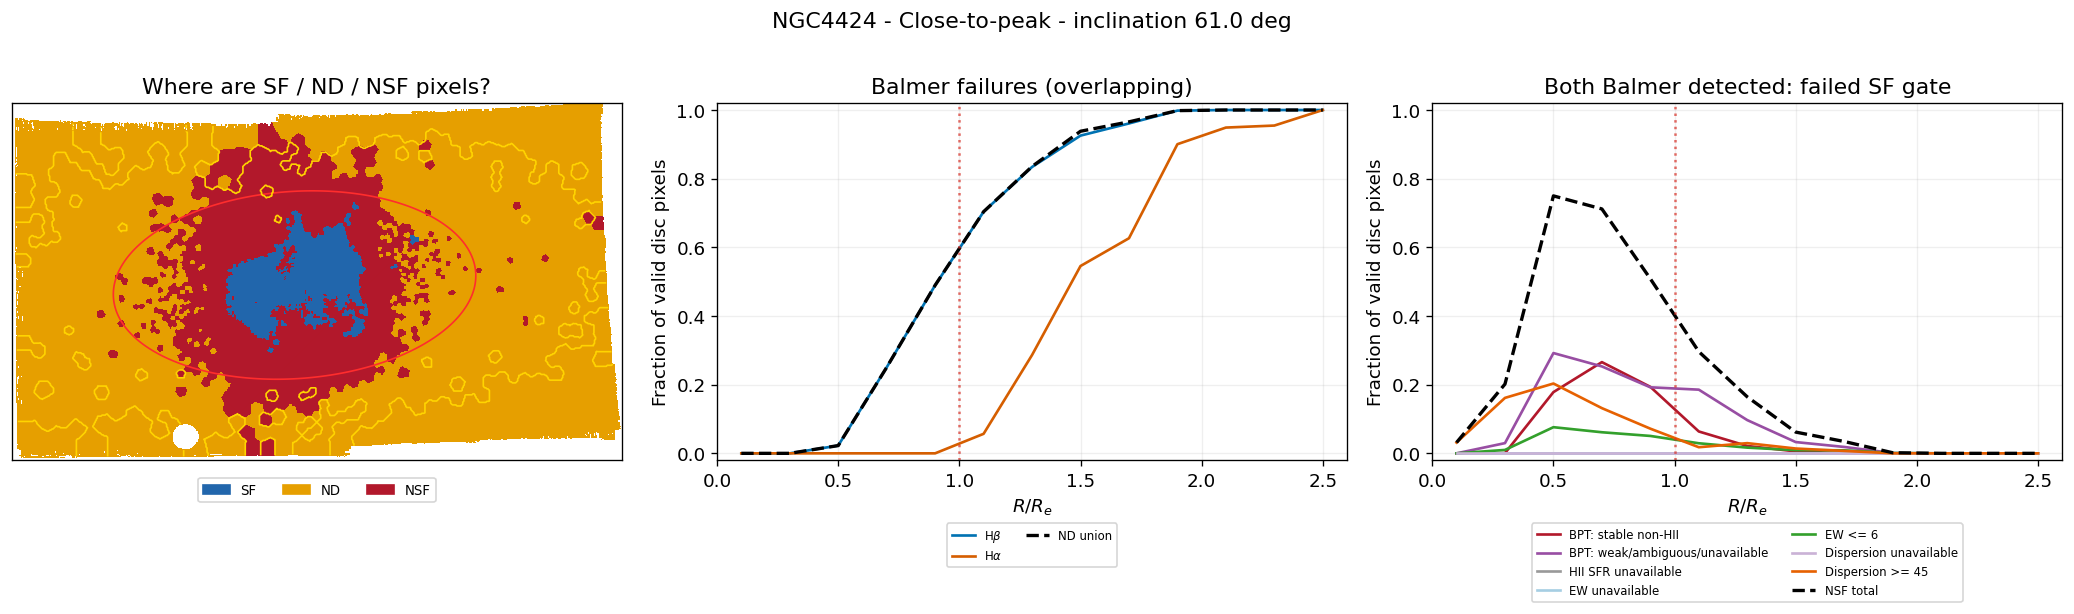

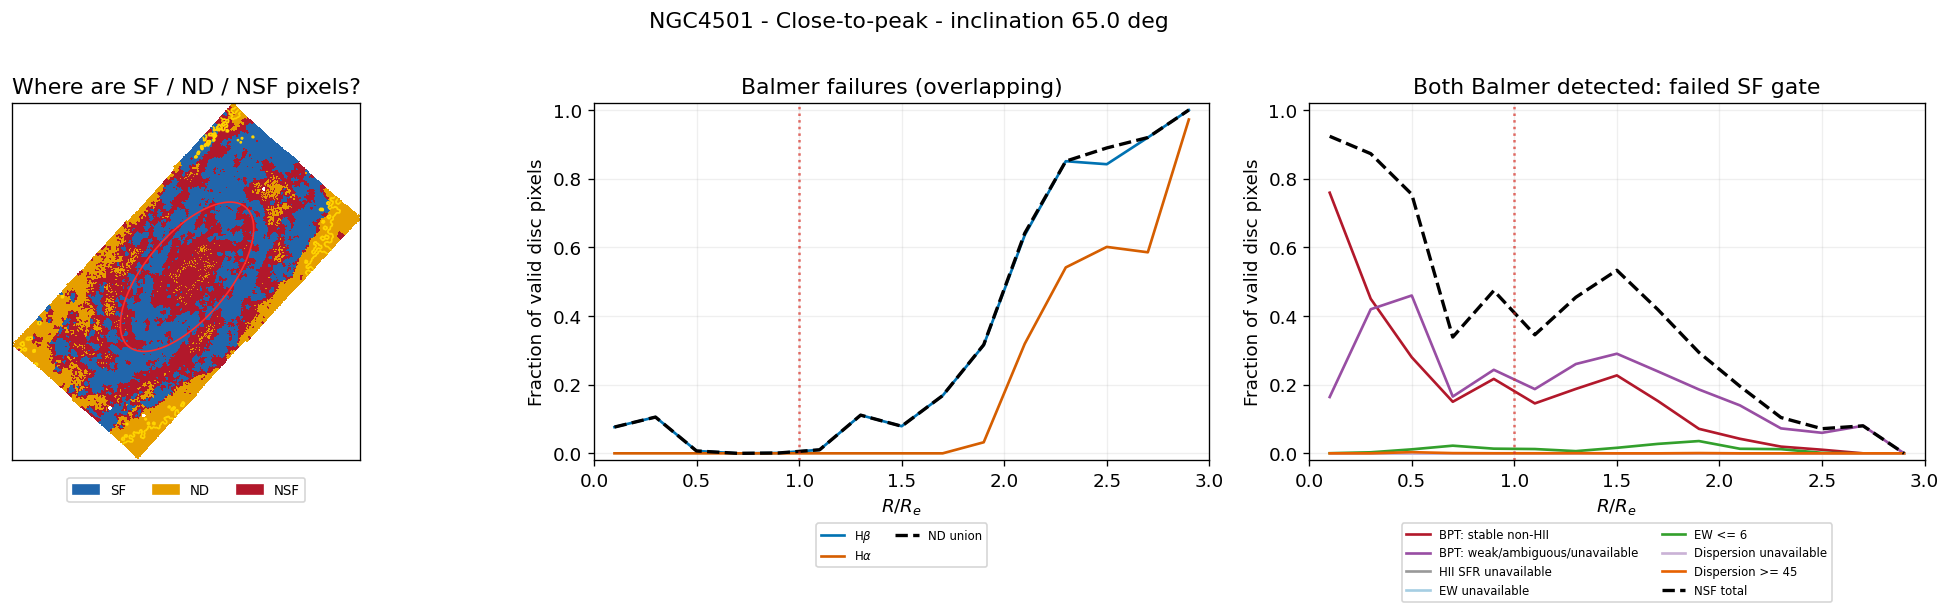

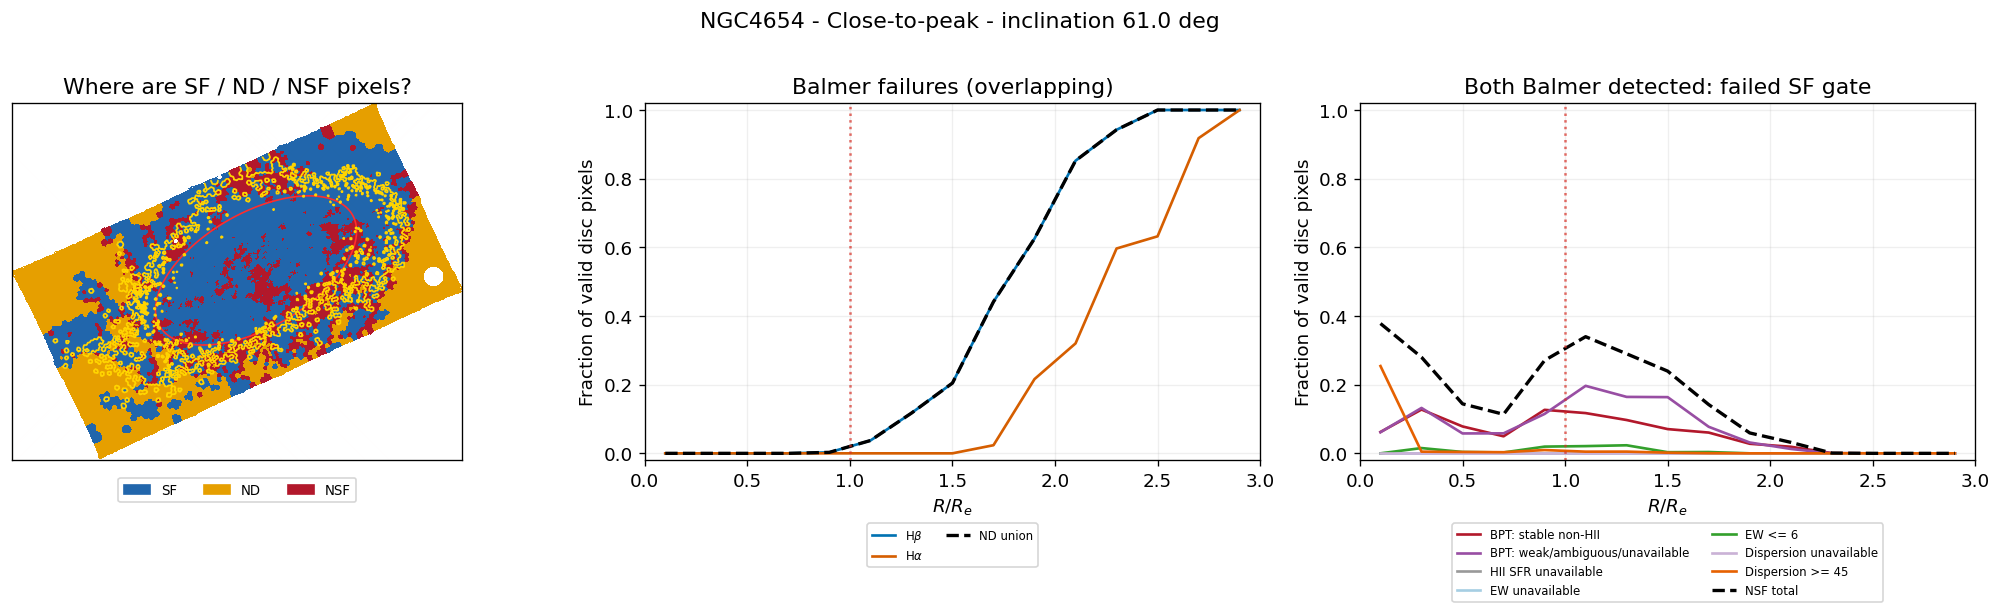

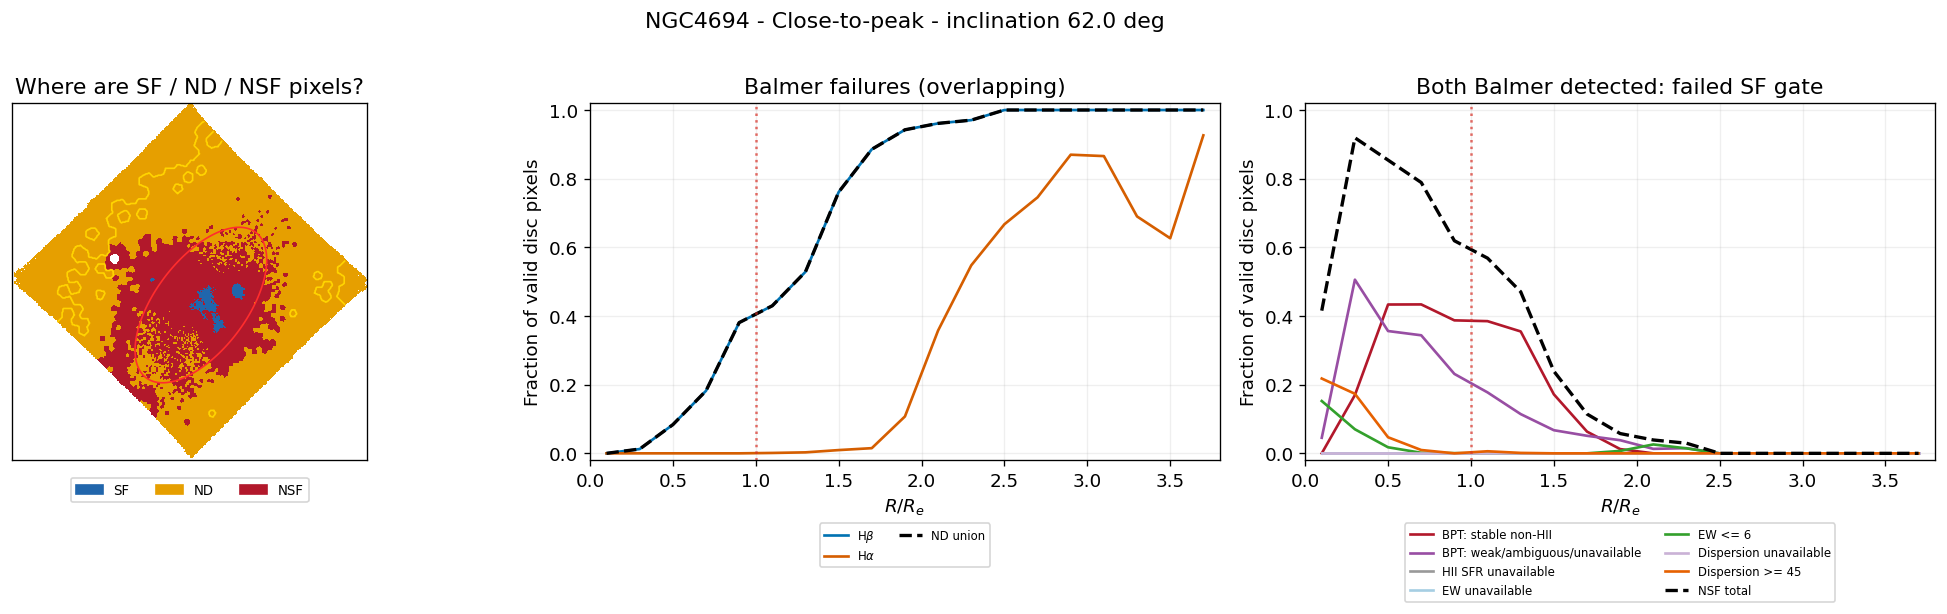

In [8]:

REASON_PROFILES = {}
for row in target_sample.itertuples(index=False):
    maps = map_cache[row.GALID]
    measurement = individual_measurements[row.GALID]
    edges = measurement["radius_edges"]
    total = measurement["fSF_by_radius"]
    fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.2))
    fig.suptitle(f"{row.GALID} - {TARGET_STAGE_LABEL} - inclination {row.inclination:.1f} deg", y=1.01)
    category = np.full(maps["valid_disc_mask"].shape, np.nan)
    for code, key in enumerate(("sf_mask", "nd_mask", "nsf_mask")):
        category[maps[key]] = code
    cmap = mpl.colors.ListedColormap([CATEGORY_COLORS[k] for k in ("SF", "ND", "NSF")])
    cmap.set_bad("white")
    axes[0].imshow(np.ma.masked_invalid(category), origin="lower", cmap=cmap,
                   vmin=-0.5, vmax=2.5, interpolation="nearest")
    axes[0].contour(maps["radius_re"], levels=[1], colors="#ff2d2d", linewidths=1.0)
    axes[0].contour(maps["log_sigma_star"], levels=[MASS_CONTOUR_LEVEL],
                    colors="#ffd400", linewidths=1.0)
    axes[0].set(title="Where are SF / ND / NSF pixels?", xticks=[], yticks=[])
    axes[0].legend(handles=[mpl.patches.Patch(color=CATEGORY_COLORS[k], label=k)
                            for k in ("SF", "ND", "NSF")],
                   loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, fontsize=8)
    line_profiles, reason_profiles = {}, {}
    line_colors = ("#0072b2", "#d55e00")
    for line, label, color in zip(BALMER_LINES, LINE_LABELS, line_colors):
        mask = maps["valid_disc_mask"] & ~maps["line_detected"][line]
        tab = binned_fraction(maps["radius_re"], maps["valid_disc_mask"], mask, edges)
        line_profiles[line] = tab.rename(columns={"N_SF": "N_failed", "f_SF": "f_failed"})
        axes[1].plot(tab.center, tab.f_SF, color=color, label=label, lw=1.6)
    axes[1].plot(total.center, total.f_ND, "k--", lw=2, label="ND union")
    axes[1].set(title="Balmer failures (overlapping)")
    for label, color in zip(REASON_LABELS, REASON_COLORS):
        tab = binned_fraction(maps["radius_re"], maps["valid_disc_mask"],
                              maps["nsf_reasons"][label], edges)
        reason_profiles[label] = tab.rename(columns={"N_SF": "N_reason", "f_SF": "f_reason"})
        axes[2].plot(tab.center, tab.f_SF, color=color, label=label, lw=1.6)
    reason_sum = sum(tab.N_reason.to_numpy() for tab in reason_profiles.values())
    assert np.array_equal(reason_sum, total.N_NSF.to_numpy())
    axes[2].plot(total.center, total.f_NSF, "k--", lw=2, label="NSF total")
    axes[2].set(title="Both Balmer detected: failed SF gate")
    REASON_PROFILES[row.GALID] = {"line_failures": line_profiles, "NSF_reasons": reason_profiles}
    for ax in axes[1:]:
        ax.set(xlabel=r"$R/R_e$", ylabel="Fraction of valid disc pixels",
               xlim=(edges[0], edges[-1]), ylim=(-0.02, 1.02))
        ax.axvline(1, color="#d73027", ls=":", alpha=0.7)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [9]:
# Regenerate this concise reading from the current tables on every run.
n_nd_larger = int((CATEGORY_SUMMARY.f_ND > CATEGORY_SUMMARY.f_NSF).sum())
print(f"Balmer ND exceeds NSF in {n_nd_larger}/{len(CATEGORY_SUMMARY)} product footprints.")
for column, label in (("f_ND", "ND"), ("f_NSF", "NSF (both Balmer detected)")):
    row = CATEGORY_SUMMARY.loc[CATEGORY_SUMMARY[column].idxmax()]
    print(f"Largest {label} fraction: {row.GALID}; "
          f"SF={row.f_SF:.1%}, ND={row.f_ND:.1%}, NSF={row.f_NSF:.1%} of valid pixels.")
print("Verified: every original SF pixel has both Balmer lines detected.")
print(f"ND pixels with unavailable/invalid Balmer measurements: "
      f"{CATEGORY_SUMMARY.N_ND_invalid_measurement.sum():,}; "
      "other ND pixels have measured Balmer flux/error but fail at least one Balmer detection cut.")
dominant = NSF_REASON_COUNTS.loc[
    NSF_REASON_COUNTS.groupby("GALID").N_pixels.idxmax()
].copy()
dominant = dominant.merge(CATEGORY_SUMMARY[["GALID", "N_NSF"]], on="GALID", validate="one_to_one")
dominant["fraction_of_NSF"] = dominant.N_pixels / dominant.N_NSF.replace(0, np.nan)
print("Largest first-failed gate within each product's NSF category (both Balmer detected):")
display(dominant[["GALID", "reason", "N_pixels", "fraction_of_valid", "fraction_of_NSF"]].round(4))
print("These are descriptive selection outcomes within the observed valid footprint; "
      "they do not establish a physical cause or prove that star formation is absent.")


Balmer ND exceeds NSF in 4/5 product footprints.
Largest ND fraction: NGC4424; SF=5.2%, ND=72.2%, NSF=22.6% of valid pixels.
Largest NSF (both Balmer detected) fraction: NGC4501; SF=37.9%, ND=22.4%, NSF=39.7% of valid pixels.
Verified: every original SF pixel has both Balmer lines detected.
ND pixels with unavailable/invalid Balmer measurements: 0; other ND pixels have measured Balmer flux/error but fail at least one Balmer detection cut.
Largest first-failed gate within each product's NSF category (both Balmer detected):
These are descriptive selection outcomes within the observed valid footprint; they do not establish a physical cause or prove that star formation is absent.


,GALID,reason,N_pixels,fraction_of_valid,fraction_of_NSF
0,NGC4298,BPT: weak/ambiguous/unavailable,20074,0.0403,0.4558
1,NGC4424,BPT: weak/ambiguous/unavailable,17091,0.0990,0.4385
2,NGC4501,BPT: weak/ambiguous/unavailable,147612,0.2222,0.5603
3,NGC4654,BPT: weak/ambiguous/unavailable,68022,0.1032,0.5468
4,NGC4694,BPT: stable non-HII,16205,0.1714,0.5754


### Reading the fraction and selection-audit results

- Compare orange ND and red NSF at the same stellar density or radius to identify
  whether rejected pixels lack adequate Balmer detections or fail SF selection
  despite both Balmer detections. Use the category map to locate these pixels.
- Use the two Balmer-failure profiles to distinguish failure of Halpha, Hbeta,
  or both. A failed cut can reflect the flux floor rather than low S/N.
- Check the NSF breakdown before interpreting the red curve: weak forbidden
  lines or ambiguous BPT classification, low EW, high dispersion, and unavailable
  measurements are different outcomes. NSF is not proof of absent star formation.
- The blue SF selection definition is unchanged from the source notebook. All original selected SF pixels must
  pass both Balmer detection cuts; the code verifies this, rather than defining
  another SF-with-detection fraction. No six-line detection gate is added to SF.

This remains a close-to-peak-target descriptive selection audit. The only pre-peak
content is the fixed rSFMS background, contour, and equal-galaxy SF reference fit.
No other-stage target analysis, pooled environmental inference, or independent-spaxel
significance is added. No pipeline/FITS files or external figures/tables are written.

## 7. Target all-spaxel rSFMS ordinates and fixed pre-peak reference cache

Cache `LOGSFR_SURFACE_DENSITY` for both the close-to-peak targets and the pre-peak
reference galaxies. Category-coverage, ND-detail, and runtime provenance tables
refer only to the coloured target sample. The pre-peak cache is used only for the
fixed light-gray SF background, SF+ND+NSF contour, and black reference OLS.

In [10]:
CATEGORY_KEYS = {"SF": "sf_mask", "ND": "nd_mask", "NSF": "nsf_mask"}
rsfms_cache = {}
coverage_rows, provenance_rows, nd_rows = [], [], []
analysis_sample = pd.concat([reference_prepeak, target_sample], ignore_index=True)
analysis_sample = analysis_sample.drop_duplicates("GALID").reset_index(drop=True)
target_ids = set(target_sample.GALID)

for row in analysis_sample.itertuples(index=False):
    maps = map_cache[row.GALID]
    x = maps["log_sigma_star"]
    y, y_header = load_fits_map(row.sfr_path, ALL_SFR_HDU, return_header=True)
    valid = maps["valid_disc_mask"]
    if y.shape != x.shape:
        raise ValueError(f"{row.GALID}: all-spaxel SFR map shape mismatch")
    separation = celestial_wcs_separation_arcsec(maps["mass_header"], y_header, x.shape)
    if not np.isfinite(separation) or separation > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: all-spaxel SFR WCS mismatch")
    finite_xy = valid & np.isfinite(x) & np.isfinite(y)
    sf = maps["sf_mask"]
    if not np.all(finite_xy[sf]):
        raise AssertionError(f"{row.GALID}: selected SF has an unavailable ordinate")
    np.testing.assert_allclose(
        y[sf], maps["log_sigma_sfr"][sf], rtol=0, atol=1e-10,
        err_msg=f"{row.GALID}: all-spaxel map disagrees with original SF values",
    )
    class_sum = sum(maps[key].astype(np.int8) for key in CATEGORY_KEYS.values())
    np.testing.assert_array_equal(class_sum, valid.astype(np.int8))
    rsfms_cache[row.GALID] = {"x": x, "y": y, "finite_xy": finite_xy}

    # Coverage and ND-construction tables describe only the coloured target sample.
    if row.GALID not in target_ids:
        continue
    for label, key in CATEGORY_KEYS.items():
        selected = maps[key]
        n_class = int(selected.sum())
        n_plotted = int((selected & finite_xy).sum())
        coverage_rows.append({
            "GALID": row.GALID, "category": label,
            "N_valid": int(valid.sum()), "N_class": n_class,
            "fraction_of_valid": n_class / int(valid.sum()),
            "N_plotted": n_plotted, "N_missing_y": n_class - n_plotted,
        })

    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        raw_ha = np.asarray(hdul["HA6562_FLUX"].data, dtype=float)
        corrected_ha = np.asarray(hdul["HA6562_FLUX_CORR"].data, dtype=float)
        floor = float(header["NOISE"])
        calibration_mask = (finite_xy & maps["balmer_detected_mask"]
                            & np.isfinite(corrected_ha) & (corrected_ha > 0))
        if not calibration_mask.any():
            raise AssertionError(f"{row.GALID}: no detected pixels to verify flux conversion")
        offset_samples = y[calibration_mask] - np.log10(corrected_ha[calibration_mask])
        log_offset = float(np.median(offset_samples))
        np.testing.assert_allclose(offset_samples, log_offset, rtol=0, atol=1e-6)
        check_nd = maps["nd_mask"] & finite_xy & np.isfinite(raw_ha)
        expected_nd = np.log10(np.maximum(floor, raw_ha[check_nd])) + log_offset
        np.testing.assert_allclose(
            y[check_nd], expected_nd, rtol=0, atol=1e-6,
            err_msg=f"{row.GALID}: stored ND construction differs from current pipeline",
        )
        max_delta = (float(np.max(np.abs(y[check_nd] - expected_nd)))
                     if check_nd.any() else np.nan)
        provenance_rows.append({
            "GALID": row.GALID, "sfr_path": str(row.sfr_path),
            "ordinate_HDU": ALL_SFR_HDU, "stored_BUNIT": y_header.get("BUNIT", ""),
            **{key: header.get(key, "not recorded")
               for key in ("CUT_SN", "NOISE", "BPTMODE", "DUSTLAW", "SFRCOEF")},
            "ND_checked": int(check_nd.sum()), "ND_max_delta_dex": max_delta,
        })
        nd = maps["nd_mask"]
        ha_det, hb_det = maps["line_detected"]["HA6562"], maps["line_detected"]["HB4861"]
        nd_rows.append({
            "GALID": row.GALID, "N_ND": int(nd.sum()),
            "Halpha_detected_Hbeta_failed": int((nd & ha_det & ~hb_det).sum()),
            "Halpha_failed_Hbeta_detected": int((nd & ~ha_det & hb_det).sum()),
            "both_failed": int((nd & ~ha_det & ~hb_det).sum()),
            "invalid_Balmer_measurement": int(maps["nd_invalid_mask"].sum()),
            "ND_at_raw_Halpha_floor": int((check_nd & (raw_ha <= floor)).sum()),
        })

CATEGORY_COVERAGE = pd.DataFrame(coverage_rows)
SFR_PROVENANCE = pd.DataFrame(provenance_rows)
ND_DETAILS = pd.DataFrame(nd_rows)
assert (CATEGORY_COVERAGE.N_plotted + CATEGORY_COVERAGE.N_missing_y
        == CATEGORY_COVERAGE.N_class).all()
assert np.array_equal(
    ND_DETAILS[["Halpha_detected_Hbeta_failed", "Halpha_failed_Hbeta_detected",
                "both_failed"]].sum(axis=1).to_numpy(),
    ND_DETAILS.N_ND.to_numpy(),
)
display(CATEGORY_COVERAGE)
display(ND_DETAILS)
display(SFR_PROVENANCE)
print(f"Verified: target {TARGET_STAGE} SF/ND/NSF partition the original valid footprints.")
print("Verified: target and pre-peak-reference selected-SF ordinates equal the original HII-map values.")
print("Verified: finite target ND values follow the stored raw-Halpha/floor substitution.")
print("Stored BUNIT is reported verbatim; axis units follow the pipeline surface-density definition.")


Verified: target close-to-peak SF/ND/NSF partition the original valid footprints.
Verified: target and pre-peak-reference selected-SF ordinates equal the original HII-map values.
Verified: finite target ND values follow the stored raw-Halpha/floor substitution.
Stored BUNIT is reported verbatim; axis units follow the pipeline surface-density definition.


,GALID,category,N_valid,N_class,fraction_of_valid,N_plotted,N_missing_y
0,NGC4298,SF,498540,144157,0.289158,144157,0
1,NGC4298,ND,498540,310344,0.622506,310344,0
2,NGC4298,NSF,498540,44039,0.088336,44039,0
3,NGC4424,SF,172561,8994,0.052121,8994,0
4,NGC4424,ND,172561,124594,0.722029,124594,0
5,NGC4424,NSF,172561,38973,0.225851,38973,0
6,NGC4501,SF,664236,251936,0.379287,251936,0
7,NGC4501,ND,664236,148840,0.224077,148840,0
8,NGC4501,NSF,664236,263460,0.396636,263460,0
9,NGC4654,SF,659231,345036,0.523392,345036,0


,GALID,N_ND,Halpha_detected_Hbeta_failed,Halpha_failed_Hbeta_detected,both_failed,invalid_Balmer_measurement,ND_at_raw_Halpha_floor
0,NGC4298,310344,72750,1616,235978,0,237594
1,NGC4424,124594,60245,506,63843,0,64349
2,NGC4501,148840,95113,1226,52501,0,53706
3,NGC4654,189799,136595,0,53204,0,53204
4,NGC4694,65319,44113,0,21206,0,21206


,GALID,sfr_path,ordinate_HDU,stored_BUNIT,CUT_SN,NOISE,BPTMODE,DUSTLAW,SFRCOEF,ND_checked,ND_max_delta_dex
0,NGC4298,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,310344,4.440892e-15
1,NGC4424,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,124594,7.105427e-15
2,NGC4501,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,148840,3.552714e-15
3,NGC4654,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,189799,1.021405e-14
4,NGC4694,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,LOGSFR_SURFACE_DENSITY,1,3,20,both,calzetti,4.983582e-42,65319,4.440892e-15


## 8. Fixed pre-peak equal-galaxy OLS and individual close-to-peak guides

The black reference fits $y=a(x-8)+b_8$ to all selected-SF pixels from the
pre-peak reference. Each pre-peak spaxel in galaxy $g$ has
$w_{ig}=1/N_{\mathrm{SF},g}$, so every reference galaxy has equal total
weight. The blue line in each panel is an ordinary unweighted OLS fit to the
selected-SF pixels of that individual close-to-peak target.

Neither target ND nor target NSF points enter either fit. Display subsampling,
axis cuts, and the dotted contour do not enter the regressions. Pixels may share
the PSF or fitted bins; no independent-spaxel uncertainties or environmental
significance are inferred.

In [11]:
OLS_PIVOT = 8.0
MIN_OLS_PIXELS = 20


def ols_guide(x, y, weights=None):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if x.shape != y.shape:
        raise ValueError("x and y must have matching shapes")
    if weights is None:
        weights = np.ones(x.shape, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
        if weights.shape != x.shape:
            raise ValueError("weights must match x and y")
    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(weights) & (weights > 0)
    x, y, weights = x[good], y[good], weights[good]
    result = {
        "N_SF": int(x.size), "sum_weight": float(weights.sum()),
        "slope": np.nan, "intercept_at_8": np.nan,
        "x_min": np.nan, "x_max": np.nan, "status": "insufficient_SF",
    }
    if x.size < MIN_OLS_PIXELS:
        return result
    xmean = float(np.average(x, weights=weights))
    ymean = float(np.average(y, weights=weights))
    centered_x = x - xmean
    denominator = float(np.dot(weights, centered_x**2))
    if denominator <= 0:
        result["status"] = "zero_mass_spread"
        return result
    slope = float(np.dot(weights * centered_x, y - ymean) / denominator)
    result.update(
        slope=slope,
        intercept_at_8=ymean + slope * (OLS_PIVOT - xmean),
        x_min=float(x.min()), x_max=float(x.max()), status="OK",
    )
    return result


# Fixed reference: all finite pre-peak SF+ND+NSF points and all selected-SF points.
pooled_x = np.concatenate([rsfms_cache[g]["x"][rsfms_cache[g]["finite_xy"]]
                           for g in reference_prepeak.GALID])
pooled_y = np.concatenate([rsfms_cache[g]["y"][rsfms_cache[g]["finite_xy"]]
                           for g in reference_prepeak.GALID])

pooled_sf_x_parts, pooled_sf_y_parts, pooled_sf_weight_parts = [], [], []
reference_weight_rows = []
for galid in reference_prepeak.GALID:
    sf_mask = map_cache[galid]["sf_mask"]
    sf_x = rsfms_cache[galid]["x"][sf_mask]
    sf_y = rsfms_cache[galid]["y"][sf_mask]
    n_sf = int(sf_x.size)
    if n_sf == 0:
        raise RuntimeError(f"{galid}: no selected-SF pixels for equal-galaxy pre-peak reference fit")
    sf_weights = np.full(n_sf, 1.0 / n_sf, dtype=float)
    pooled_sf_x_parts.append(sf_x)
    pooled_sf_y_parts.append(sf_y)
    pooled_sf_weight_parts.append(sf_weights)
    reference_weight_rows.append({
        "GALID": galid, "N_SF": n_sf,
        "weight_per_SF_spaxel": 1.0 / n_sf,
        "total_weight": float(sf_weights.sum()),
    })

pooled_sf_x = np.concatenate(pooled_sf_x_parts)
pooled_sf_y = np.concatenate(pooled_sf_y_parts)
pooled_sf_weights = np.concatenate(pooled_sf_weight_parts)
REFERENCE_GALAXY_WEIGHT_SUMMARY = pd.DataFrame(reference_weight_rows)

expected_reference_xy = sum(int(rsfms_cache[g]["finite_xy"].sum()) for g in reference_prepeak.GALID)
expected_reference_sf = sum(int(map_cache[g]["sf_mask"].sum()) for g in reference_prepeak.GALID)
assert pooled_x.size == expected_reference_xy
assert pooled_sf_x.size == expected_reference_sf
np.testing.assert_allclose(REFERENCE_GALAXY_WEIGHT_SUMMARY.total_weight, 1.0, rtol=0, atol=1e-12)
np.testing.assert_allclose(pooled_sf_weights.sum(), len(reference_prepeak), rtol=0, atol=1e-12)

reference_ensemble_ols = ols_guide(pooled_sf_x, pooled_sf_y, weights=pooled_sf_weights)
individual_ols = {}
for galid in target_sample.GALID:
    mask = map_cache[galid]["sf_mask"]
    data = rsfms_cache[galid]
    individual_ols[galid] = ols_guide(data["x"][mask], data["y"][mask])

OLS_SUMMARY = pd.DataFrame(
    [{"sample": "All pre-peak selected SF reference", "stage": REFERENCE_STAGE,
      "N_galaxies": len(reference_prepeak), "weighting": "equal galaxy (w=1/N_SF,g)",
      **reference_ensemble_ols}]
    + [{"sample": g, "stage": TARGET_STAGE, "N_galaxies": 1,
        "weighting": "unweighted individual", **individual_ols[g]}
       for g in target_sample.GALID]
)
display(REFERENCE_GALAXY_WEIGHT_SUMMARY)
display(OLS_SUMMARY)
print(f"Grey pre-peak reference: {pooled_sf_x.size:,} selected-SF pixels from "
      f"{len(reference_prepeak)} products.")
print(f"Dotted pre-peak outline inputs: {pooled_x.size:,} finite SF+ND+NSF pixels.")
print(f"Black pre-peak OLS: {pooled_sf_x.size:,} selected-SF pixels with w=1/N_SF,g; "
      f"each of {len(reference_prepeak)} reference galaxies has equal total weight 1.")
print(f"Blue individual OLS fits: {len(target_sample)} {TARGET_STAGE} target products; unweighted SF pixels.")


Grey pre-peak reference: 1,746,860 selected-SF pixels from 8 products.
Dotted pre-peak outline inputs: 3,812,578 finite SF+ND+NSF pixels.
Black pre-peak OLS: 1,746,860 selected-SF pixels with w=1/N_SF,g; each of 8 reference galaxies has equal total weight 1.
Blue individual OLS fits: 5 close-to-peak target products; unweighted SF pixels.


,GALID,N_SF,weight_per_SF_spaxel,total_weight
0,NGC4189,96364,0.000010,1.0
1,NGC4254,661963,0.000002,1.0
2,NGC4294,68833,0.000015,1.0
3,NGC4321,454131,0.000002,1.0
4,NGC4351,30711,0.000033,1.0
5,NGC4383,25212,0.000040,1.0
6,NGC4535,187113,0.000005,1.0
7,NGC4567_8,222533,0.000004,1.0


,sample,stage,N_galaxies,weighting,N_SF,sum_weight,slope,intercept_at_8,x_min,x_max,status
0,All pre-peak selected SF reference,pre-peak,8,"equal galaxy (w=1/N_SF,g)",1746860,8.0,0.959663,-2.010912,6.380377,10.368964,OK
1,NGC4298,close-to-peak,1,unweighted individual,144157,144157.0,0.812325,-2.173250,7.159703,9.272703,OK
2,NGC4424,close-to-peak,1,unweighted individual,8994,8994.0,1.957423,-2.381107,7.676855,9.027295,OK
3,NGC4501,close-to-peak,1,unweighted individual,251936,251936.0,0.740760,-2.219132,7.143959,9.387921,OK
4,NGC4654,close-to-peak,1,unweighted individual,345036,345036.0,0.879535,-2.050915,6.445466,9.237140,OK
5,NGC4694,close-to-peak,1,unweighted individual,1058,1058.0,1.702696,-2.736779,8.094147,9.345571,OK


## 9. Individual close-to-peak rSFMS category panels

Each panel overlays one close-to-peak target galaxy on the same fixed pre-peak
reference: all pre-peak selected-SF pixels in light gray, the outer-point contour
of all finite pre-peak SF+ND+NSF pixels, and the black equal-galaxy pre-peak OLS.
The coloured points and blue OLS belong only to the named target galaxy.

The dotted outline connects actual outer pre-peak data points through a Shapely
concave hull with `OUTLINE_CONCAVITY_RATIO = 0.15`, no holes, no smoothing, and no
percentile cut. Axis limits span the union of all finite pre-peak reference and
all finite close-to-peak target points. Orange symbols remain proxy values, not formal
upper limits; red NSF values are Halpha-equivalent rejected-selection values.

Dotted outline: connected outer points of all 3,812,578 finite pre-peak SF+ND+NSF pixels; no target points, density smoothing, or percentile cut.
Verified: all finite target category pixels were plotted, with no display subsampling.


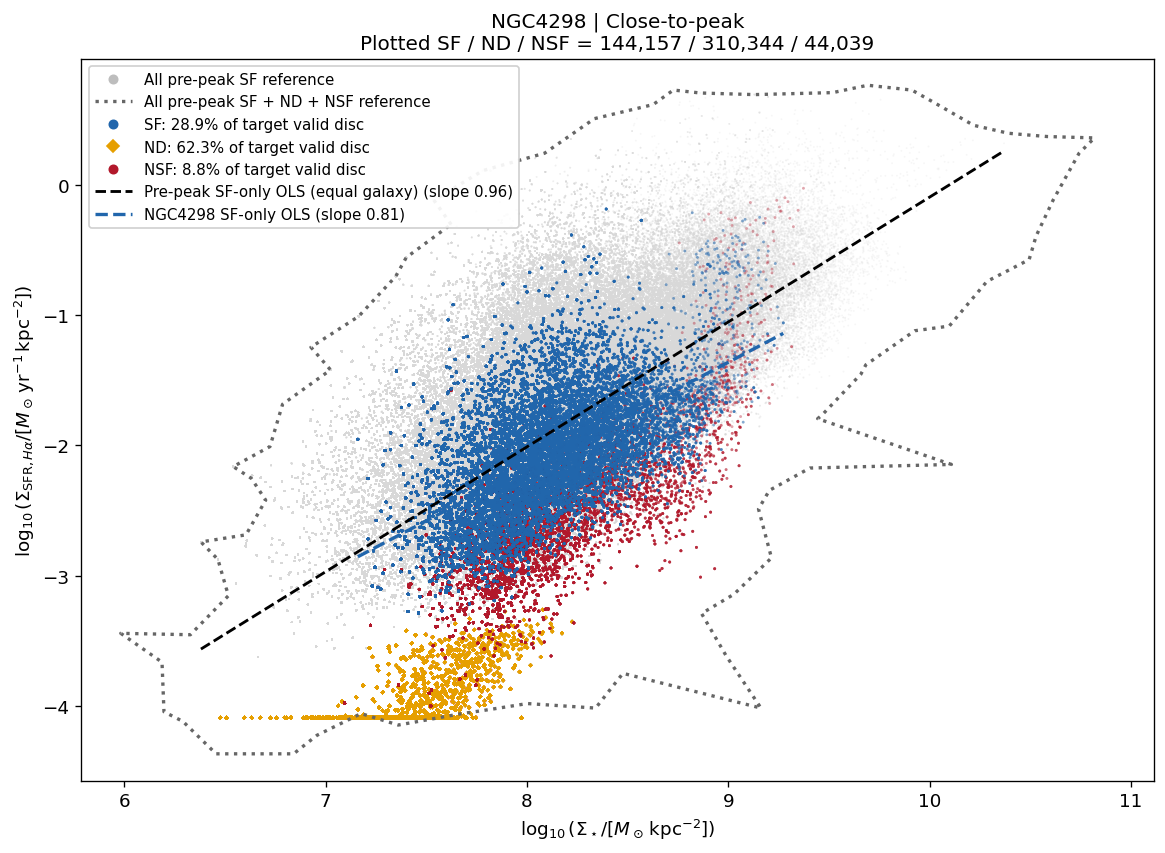

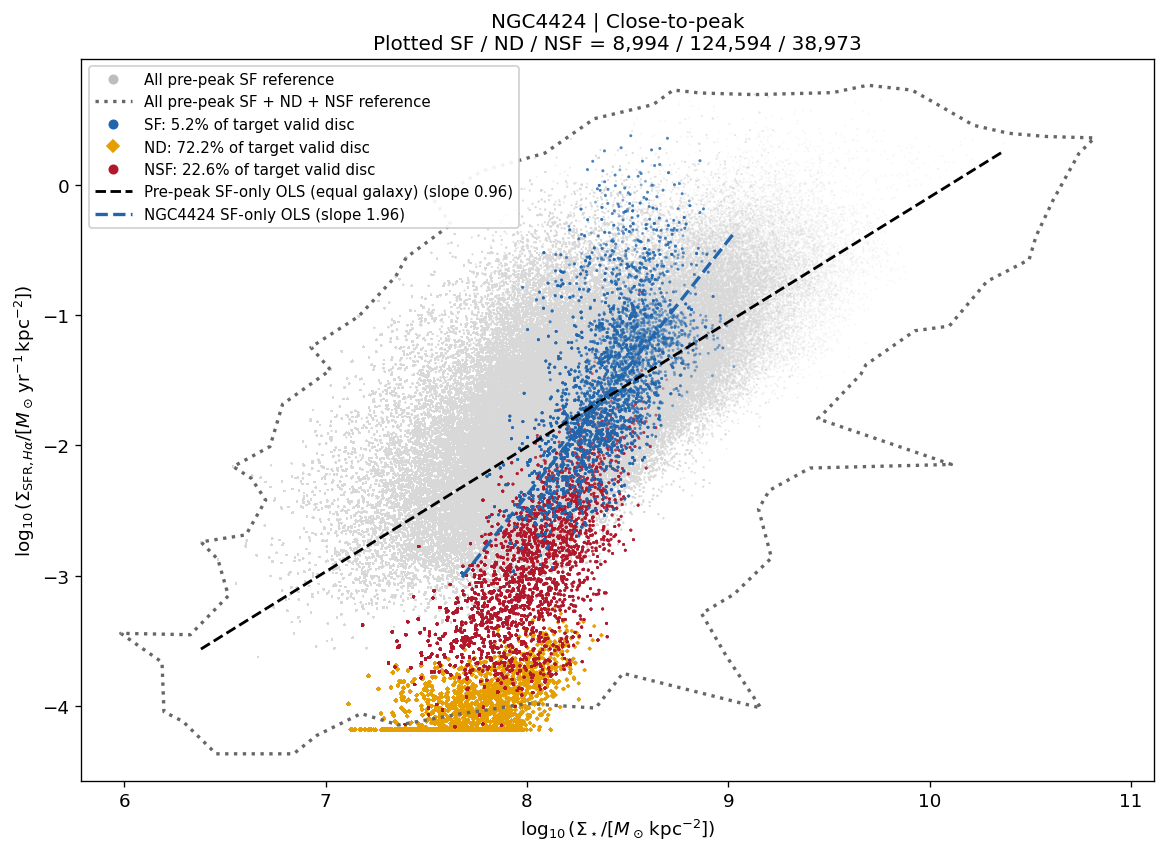

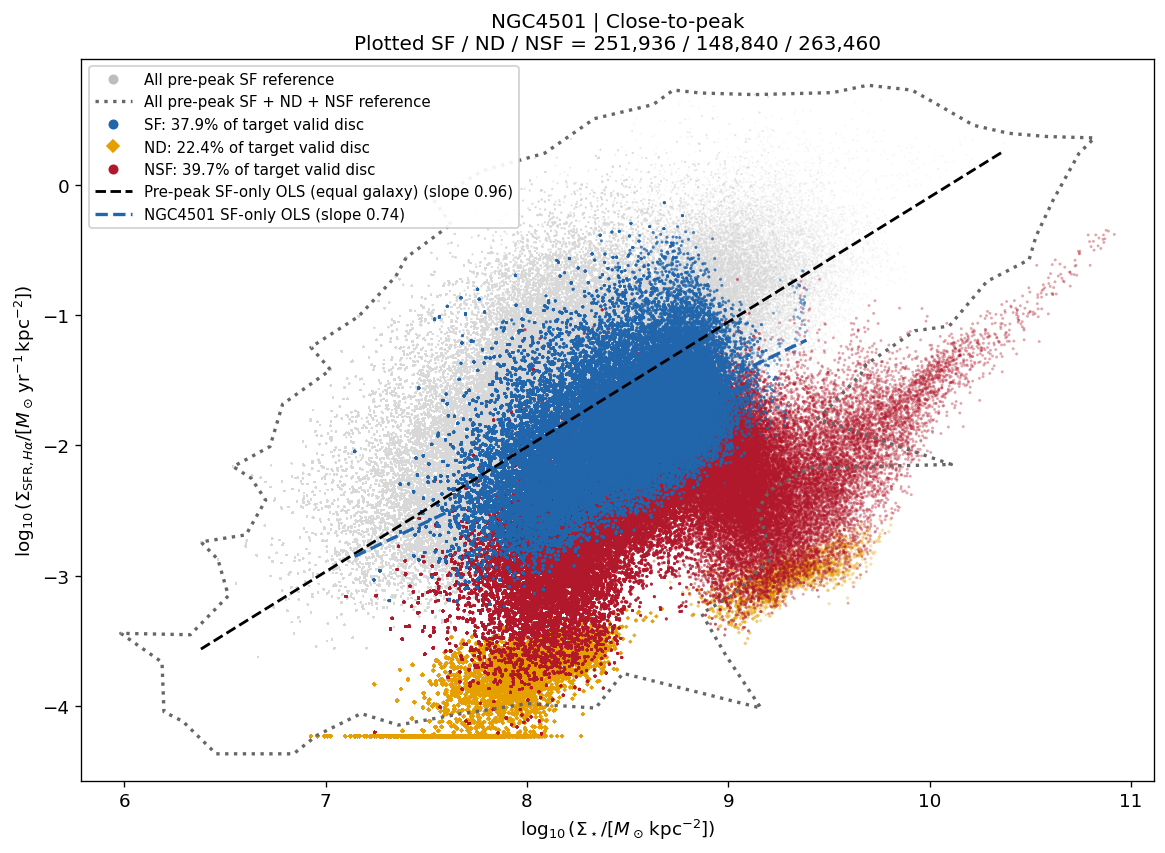

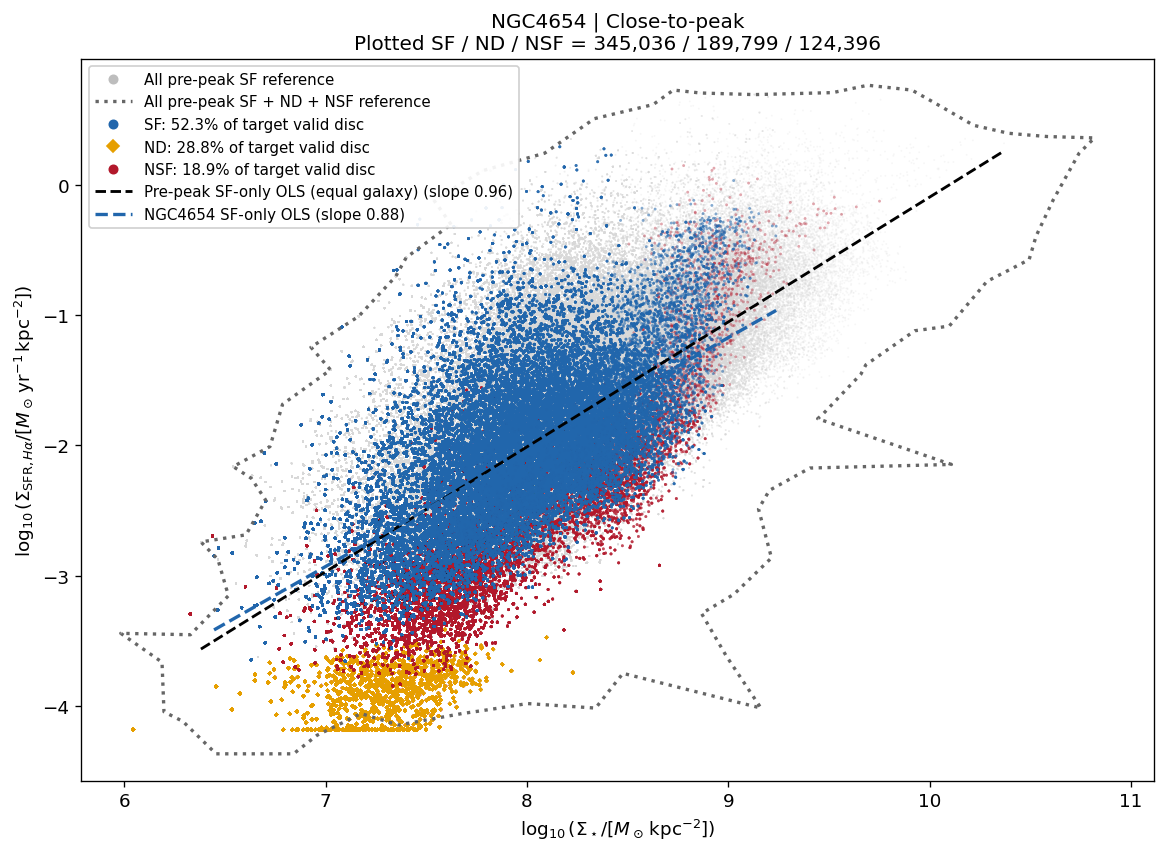

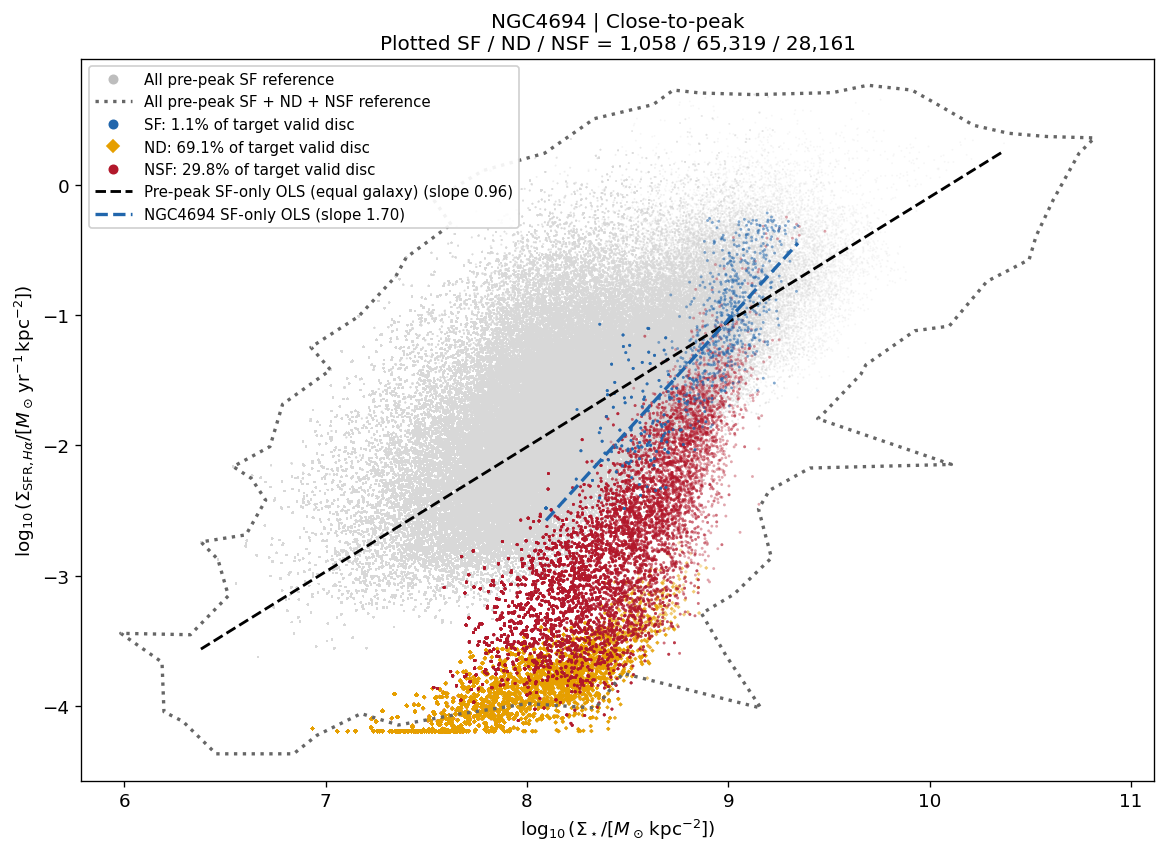

In [12]:
from matplotlib.lines import Line2D
from shapely import MultiPoint, concave_hull


def full_limits(values, padding=0.04):
    lo, hi = float(np.min(values)), float(np.max(values))
    margin = padding * max(hi - lo, 0.5)
    return lo - margin, hi + margin


OUTLINE_CONCAVITY_RATIO = 0.15
all_prepeak_points = np.unique(np.column_stack((pooled_x, pooled_y)), axis=0)
all_prepeak_hull = concave_hull(
    MultiPoint(all_prepeak_points), ratio=OUTLINE_CONCAVITY_RATIO, allow_holes=False,
)
all_prepeak_outline = np.asarray(all_prepeak_hull.exterior.coords)
print(f"Dotted outline: connected outer points of all {pooled_x.size:,} finite pre-peak "
      "SF+ND+NSF pixels; no target points, density smoothing, or percentile cut.")

target_display_x = np.concatenate([
    rsfms_cache[g]["x"][rsfms_cache[g]["finite_xy"]] for g in target_sample.GALID
])
target_display_y = np.concatenate([
    rsfms_cache[g]["y"][rsfms_cache[g]["finite_xy"]] for g in target_sample.GALID
])
X_LIMITS = full_limits(np.concatenate([pooled_x, target_display_x]))
Y_LIMITS = full_limits(np.concatenate([pooled_y, target_display_y]))
PLOT_COUNTS = []

for row in target_sample.itertuples(index=False):
    galid = row.GALID
    maps, data = map_cache[galid], rsfms_cache[galid]
    fig, ax = plt.subplots(figsize=(9.6, 7.0), layout="constrained")
    ax.scatter(pooled_sf_x, pooled_sf_y, s=1.2, color="#d8d8d8", alpha=0.22,
               edgecolors="none", rasterized=True, zorder=1)
    style = {"ND": ("D", 3.0, 0.32), "NSF": ("o", 3.0, 0.38),
             "SF": ("o", 3.0, 0.55)}
    counts = {}
    for category in ("ND", "NSF", "SF"):
        mask = maps[CATEGORY_KEYS[category]] & data["finite_xy"]
        marker, size, alpha = style[category]
        counts[category] = int(mask.sum())
        ax.scatter(data["x"][mask], data["y"][mask], s=size, marker=marker,
                   color=CATEGORY_COLORS[category], alpha=alpha, edgecolors="none",
                   rasterized=True, zorder=2 if category == "ND" else 3 if category == "NSF" else 4)
    ax.plot(all_prepeak_outline[:, 0], all_prepeak_outline[:, 1],
            color="#666666", linestyle=":", lw=2.0, zorder=5)
    line_handles = []
    for fit, color, label, width in (
        (reference_ensemble_ols, "black", "Pre-peak SF-only OLS (equal galaxy)", 1.7),
        (individual_ols[galid], CATEGORY_COLORS["SF"], f"{galid} SF-only OLS", 2.0),
    ):
        if fit["status"] == "OK":
            xx = np.linspace(fit["x_min"], fit["x_max"], 100)
            ax.plot(xx, fit["slope"] * (xx - OLS_PIVOT) + fit["intercept_at_8"],
                    color=color, linestyle="--", lw=width, zorder=6)
            line_handles.append(Line2D(
                [], [], color=color, ls="--", lw=width,
                label=f'{label} (slope {fit["slope"]:.2f})',
            ))
    n_valid = int(maps["valid_disc_mask"].sum())
    n_missing = int((maps["valid_disc_mask"] & ~data["finite_xy"]).sum())
    class_counts = {k: int(maps[v].sum()) for k, v in CATEGORY_KEYS.items()}
    handles = [Line2D([], [], color="#bdbdbd", marker="o", ls="none", ms=5,
                      label="All pre-peak SF reference"),
               Line2D([], [], color="#666666", ls=":", lw=2.0,
                      label="All pre-peak SF + ND + NSF reference")]
    handles += [
        Line2D([], [], color=CATEGORY_COLORS[k], marker=style[k][0], ls="none", ms=5,
               label=f'{k}: {class_counts[k] / n_valid:.1%} of target valid disc')
        for k in ("SF", "ND", "NSF")
    ]
    ax.legend(handles=handles + line_handles, loc="upper left", fontsize=9,
              frameon=True, framealpha=0.92, handlelength=2.5)
    ax.set(xlim=X_LIMITS, ylim=Y_LIMITS,
           xlabel=r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
           ylabel=r"$\log_{10}(\Sigma_{\mathrm{SFR},H\alpha}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$")
    ax.set_title(
        f"{galid} | {TARGET_STAGE_LABEL}\n"
        f"Plotted SF / ND / NSF = {counts['SF']:,} / {counts['ND']:,} / {counts['NSF']:,}",
        fontsize=12,
    )
    PLOT_COUNTS.append({"GALID": galid, **counts, "N_missing_y": n_missing})
    plt.show()
    plt.close(fig)

PLOT_COUNTS = pd.DataFrame(PLOT_COUNTS)
expected_counts = CATEGORY_COVERAGE.pivot(index="GALID", columns="category", values="N_plotted")
for category in CATEGORY_KEYS:
    np.testing.assert_array_equal(
        PLOT_COUNTS.set_index("GALID")[category].sort_index().to_numpy(),
        expected_counts[category].sort_index().to_numpy(),
    )
print("Verified: all finite target category pixels were plotted, with no display subsampling.")


## 10. Reading the close-to-peak diagnostic

- Compare each target category with the same light-gray pre-peak SF background,
  dotted pre-peak SF+ND+NSF contour, and black pre-peak equal-galaxy OLS.
- The blue dashed line describes only the selected-SF locus within the displayed
  close-to-peak target galaxy; it is not part of the pre-peak reference estimator.
- An ND pile-up must first be checked against the raw-Halpha floor count in
  `ND_DETAILS`; these substitutions are not formal upper limits.
- Red NSF offsets do not by themselves establish SF enhancement, suppression, or
  an upper confidence bound on the true SFR.
- The diagnostic is descriptive. A censored fit would require an explicit
  flux-limit construction, attenuation assumptions, NSF-contamination treatment,
  and a censored statistical model.

In [13]:
n_total = int(CATEGORY_COVERAGE.groupby("GALID").N_valid.first().sum())
n_missing = int(CATEGORY_COVERAGE.N_missing_y.sum())
print(f"Current target run: {len(target_sample)} {TARGET_STAGE} products; {n_total:,} valid-disc pixels.")
for category in CATEGORY_KEYS:
    subset = CATEGORY_COVERAGE.loc[CATEGORY_COVERAGE.category.eq(category)]
    print(f"{category}: {int(subset.N_class.sum()):,} class pixels; "
          f"{int(subset.N_plotted.sum()):,} finite plotted ordinates; "
          f"{int(subset.N_missing_y.sum()):,} missing ordinates.")
print(f"Total target missing ordinates: {n_missing:,}. These remain counted in the target denominator.")
print(f"Fixed reference: {len(reference_prepeak)} pre-peak galaxies; equal total OLS weight 1 per galaxy.")
print("No target ND or NSF points enter either OLS guide. The black reference guide is pre-peak "
      "equal-galaxy weighted; each blue target guide is unweighted; no censored regression was performed.")


Current target run: 5 close-to-peak products; 2,089,106 valid-disc pixels.
SF: 751,181 class pixels; 751,181 finite plotted ordinates; 0 missing ordinates.
ND: 838,896 class pixels; 838,896 finite plotted ordinates; 0 missing ordinates.
NSF: 499,029 class pixels; 499,029 finite plotted ordinates; 0 missing ordinates.
Total target missing ordinates: 0. These remain counted in the target denominator.
Fixed reference: 8 pre-peak galaxies; equal total OLS weight 1 per galaxy.
No target ND or NSF points enter either OLS guide. The black reference guide is pre-peak equal-galaxy weighted; each blue target guide is unweighted; no censored regression was performed.


## 11. Combined synthesis and limits

- Fractions, maps, failure modes, coloured points, and blue individual OLS guides
  describe only the close-to-peak target galaxies.
- The light-gray background, dotted contour, and black equal-galaxy OLS remain
  fixed to all pre-peak reference galaxies and exclude every target point.
- SF/ND/NSF masks and the original valid-disc denominator are unchanged.
- This is a descriptive selection audit, not a censored regression or an
  independent-spaxel environmental inference.

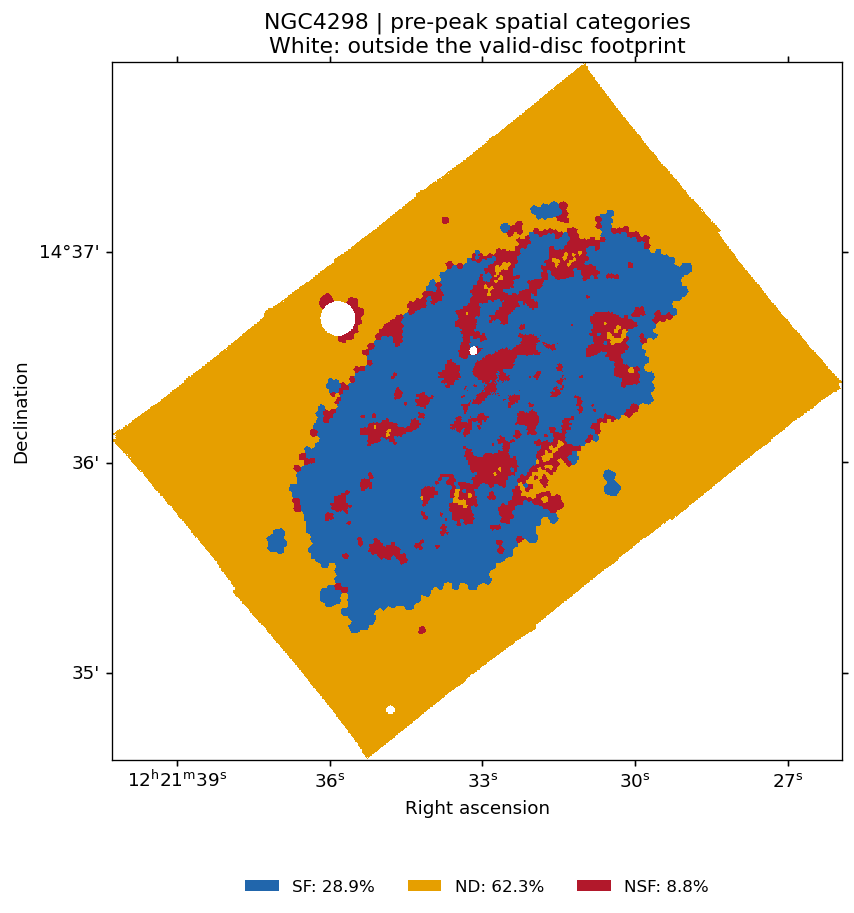

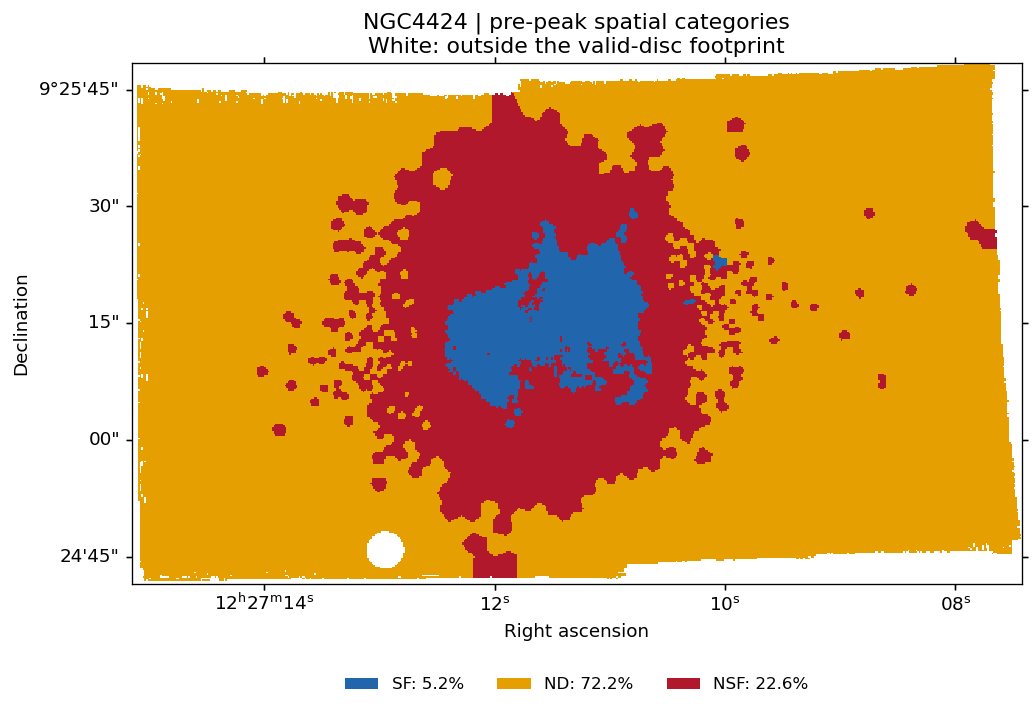

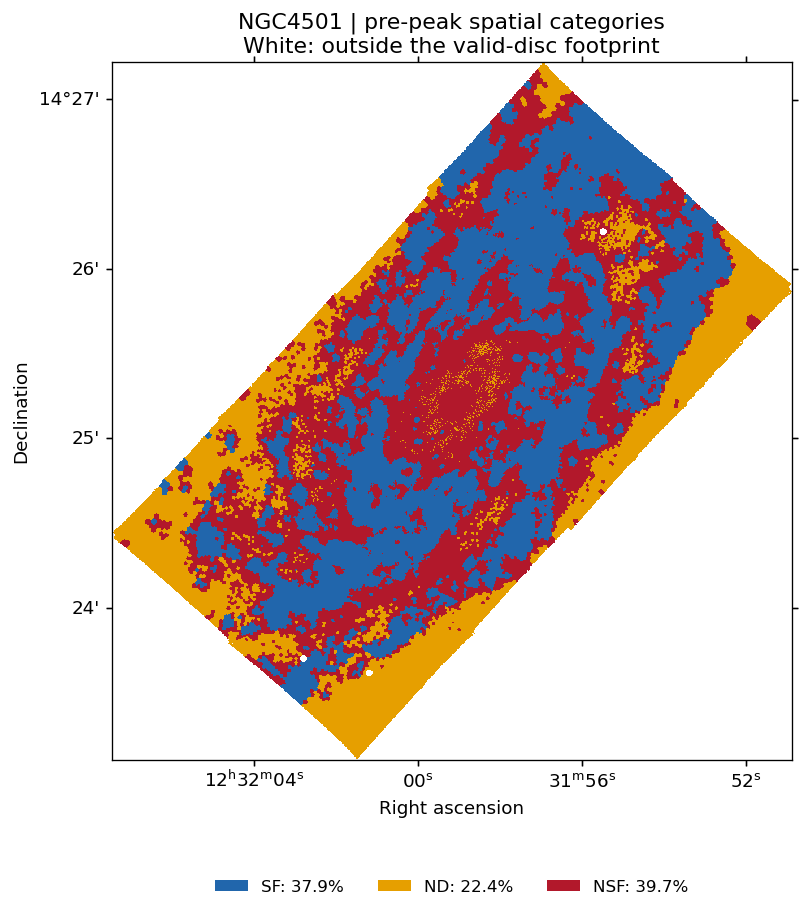

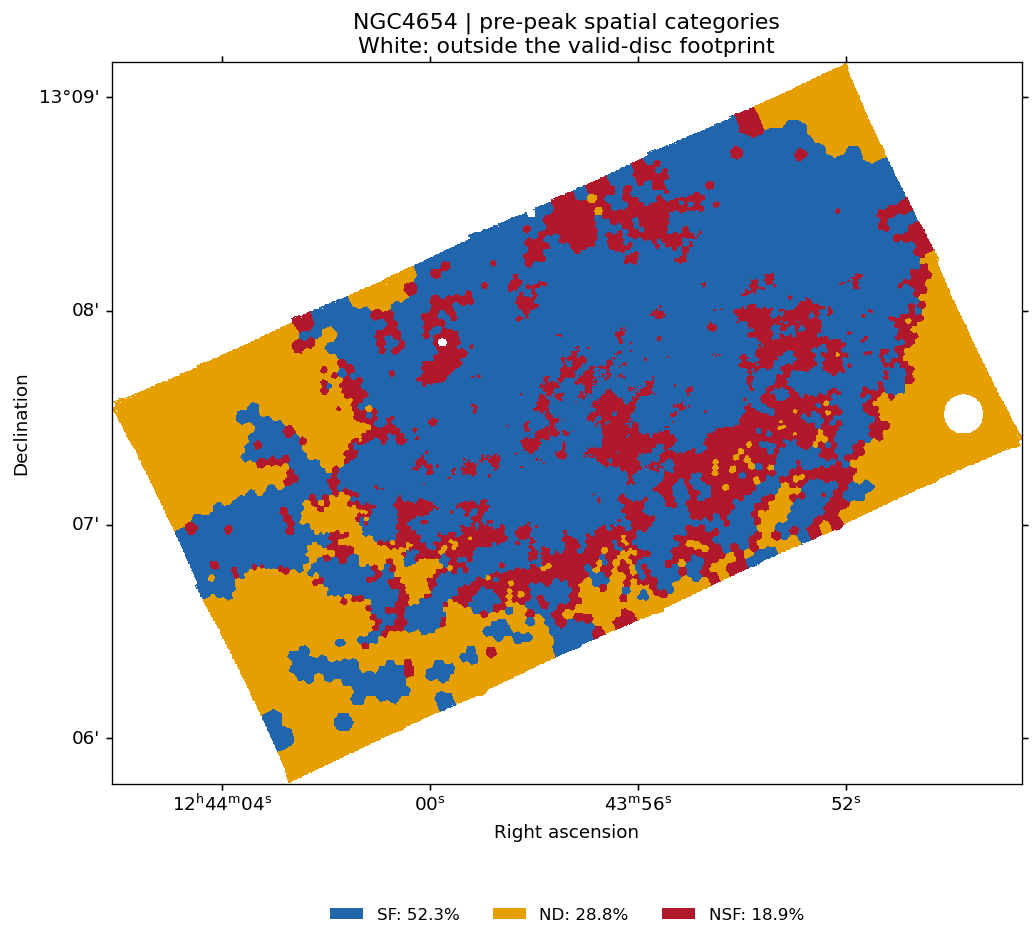

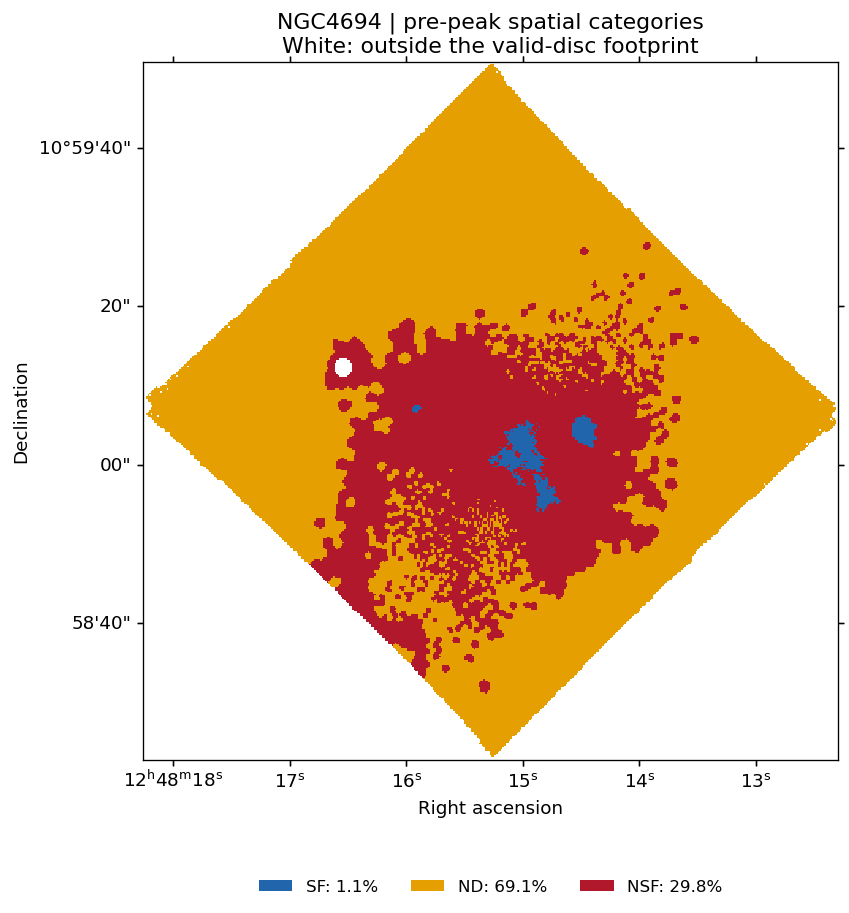

In [14]:
# Spatial SF/ND/NSF categories on the unchanged valid-disc footprint.
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

spatial_category_labels = ("SF", "ND", "NSF")
spatial_category_keys = ("sf_mask", "nd_mask", "nsf_mask")
spatial_category_cmap = ListedColormap(
    [CATEGORY_COLORS[label] for label in spatial_category_labels]
)
spatial_category_cmap.set_bad("white")
spatial_category_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)

for row in target_sample.itertuples(index=False):
    maps = map_cache[row.GALID]
    valid = maps["valid_disc_mask"]
    category_map = np.full(valid.shape, np.nan)
    for code, key in enumerate(spatial_category_keys):
        category_map[valid & maps[key]] = code

    fig = plt.figure(figsize=(8.5, 7.5), layout="constrained")
    ax = fig.add_subplot(111, projection=WCS(maps["mass_header"]).celestial)
    ax.imshow(np.ma.masked_invalid(category_map), origin="lower",
              interpolation="nearest", cmap=spatial_category_cmap,
              norm=spatial_category_norm, aspect="equal")
    ax.coords[0].set_axislabel("Right ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.set_title(f"{row.GALID} | pre-peak spatial categories\n"
                 "White: outside the valid-disc footprint")
    handles = [
        Patch(facecolor=CATEGORY_COLORS[label], edgecolor="none",
              label=f"{label}: {np.count_nonzero(valid & maps[key]) / valid.sum():.1%}")
        for label, key in zip(spatial_category_labels, spatial_category_keys)
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15),
              ncol=3, frameon=False, fontsize=10)
    plt.show()
    plt.close(fig)
